In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session



/kaggle/input/datasets/awudipeter/dataset/uci-ml-phishing-dataset.csv
/kaggle/input/datasets/awudipeter/dataset/verified_online.csv
/kaggle/input/datasets/awudipeter/dataset/knust_dataset.csv


In [3]:
import pandas as pd


PHISHTANK_PATH = "/kaggle/input/datasets/awudipeter/dataset/verified_online.csv"

UCI_PATH = "/kaggle/input/datasets/awudipeter/dataset/uci-ml-phishing-dataset.csv"

KNUST_PATH = "/kaggle/input/datasets/awudipeter/dataset/knust_dataset.csv"


# PhishTank

phishtank = pd.read_csv(
    PHISHTANK_PATH
)


phishtank = phishtank[
    ["url"]
]


phishtank["label"] = 1



# UCI

uci = pd.read_csv(
    UCI_PATH
)



print(uci.head())


   id  having_IP_Address  URL_Length  Shortining_Service  having_At_Symbol  \
0   1                 -1           1                   1                 1   
1   2                  1           1                   1                 1   
2   3                  1           0                   1                 1   
3   4                  1           0                   1                 1   
4   5                  1           0                  -1                 1   

   double_slash_redirecting  Prefix_Suffix  having_Sub_Domain  SSLfinal_State  \
0                        -1             -1                 -1              -1   
1                         1             -1                  0               1   
2                         1             -1                 -1              -1   
3                         1             -1                 -1              -1   
4                         1             -1                  1               1   

   Domain_registeration_length  ...  popUpWi

In [4]:
import os
import re
import json
import warnings
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
from urllib.parse import urlparse

from sklearn.model_selection import train_test_split
from scipy.stats import wilcoxon, spearmanr, binomtest
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, IsolationForest
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    RocCurveDisplay
)

from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier

warnings.filterwarnings("ignore")

PHISHTANK_PATH = (
    "/kaggle/input/datasets/awudipeter/dataset/knust_dataset.csv"
)

UCI_PATH = (
    "/kaggle/input/datasets/awudipeter/dataset/knust_dataset.csv"
)

KNUST_PATH = (
    "/kaggle/input/datasets/awudipeter/dataset/knust_dataset.csv"
)

# Strict opt-in. Leave as None until an independent dataset with
# exactly the same 30-feature schema is available.
EXTERNAL_PATH = None

SEEDS = [42, 7, 123, 2024, 99]
DEPTH_CANDIDATES = [3, 6, 9, 12, 15]
BASELINE_PARAMS = {
    'Logistic Regression': {'max_iter': 2000, 'solver': 'lbfgs'},
    'Decision Tree': {'random_state': 'per_seed'},
    'Random Forest': {'n_estimators': 100, 'random_state': 'per_seed', 'n_jobs': -1}
}

XGB_PARAMS = {
    "n_estimators": 500,
    "learning_rate": 0.03,
    "max_depth": 6,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "reg_lambda": 1.0,
    "objective": "binary:logistic",
    "eval_metric": "logloss"
}

OUTPUT_DIR = Path("revised_outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

print("Configuration loaded.")
print("Seeds:", SEEDS)
print("Output directory:", OUTPUT_DIR.resolve())

# ============================================================
# REPRODUCIBILITY: PYTHON / PACKAGE / RUNTIME VERSIONS
# ============================================================

import platform
from importlib.metadata import version, PackageNotFoundError

PACKAGE_NAMES = [
    "numpy", "pandas", "scikit-learn", "imbalanced-learn",
    "xgboost", "shap", "lime", "matplotlib", "scipy"
]

version_rows = []
for package in PACKAGE_NAMES:
    try:
        package_version = version(package)
    except PackageNotFoundError:
        package_version = "NOT INSTALLED"
    version_rows.append({
        "Package": package,
        "Version": package_version
    })

environment_table = pd.DataFrame(version_rows)

print("\nPython version:", platform.python_version())
print("Platform:", platform.platform())
print("\nPackage versions:")
print(environment_table.to_string(index=False))

environment_table.to_csv(
    OUTPUT_DIR / "Table_Runtime_Package_Versions.csv",
    index=False
)

with open(
    OUTPUT_DIR / "requirements_pinned.txt",
    "w",
    encoding="utf-8"
) as f:
    for row in version_rows:
        if row["Version"] != "NOT INSTALLED":
            f.write(f"{row['Package']}=={row['Version']}\n")


Configuration loaded.
Seeds: [42, 7, 123, 2024, 99]
Output directory: /kaggle/working/revised_outputs

Python version: 3.12.12
Platform: Linux-6.12.90+-x86_64-with-glibc2.35

Package versions:
         Package Version
           numpy   2.0.2
          pandas   2.2.2
    scikit-learn   1.6.1
imbalanced-learn  0.14.0
         xgboost   3.1.0
            shap  0.49.1
            lime 0.2.0.1
      matplotlib  3.10.0
           scipy  1.15.3


In [16]:
# ============================================================
# 2. PROGRAMMATIC DATA INVENTORY AND DATASET VALIDATION
# ============================================================

from pathlib import Path
from urllib.parse import urlparse

import pandas as pd
import numpy as np
import re


# ============================================================
# 2.0 DATASET PATH CONFIGURATION
# ============================================================

# Confirmed Kaggle dataset paths
PHISHTANK_PATH = (
    "/kaggle/input/datasets/awudipeter/dataset/verified_online.csv"
)

KNUST_PATH = (
    "/kaggle/input/datasets/awudipeter/dataset/knust_dataset.csv"
)

# Keep your existing UCI and External paths if already defined.
# They are intentionally not overwritten here.
#
# Example:
# UCI_PATH = "/kaggle/input/.../Phishing_Legitimate_full.csv"
# EXTERNAL_PATH = None


# ============================================================
# 2.1 EXPECTED DATASET STRUCTURES
# ============================================================

SURVEY_COLUMNS = {
    "Gender",
    "Age_Group",
    "Category",
    "Experience",
    "Trust_SHAP",
    "Trust_LIME",
    "Preferred_Explanation",
    "Trust_AI_After_SHAP"
}

EXPECTED_PHISHTANK_FEATURES = [
    "url_length",
    "domain_length",
    "digit_count",
    "special_count",
    "dot_count",
    "hyphen_count",
    "https",
    "ip_address"
]

VALID_URL_COLUMN_NAMES = {
    "url",
    "urladdress",
    "url_address",
    "website",
    "link"
}


# ============================================================
# 2.2 GENERIC FILE SUMMARY FUNCTION
# ============================================================

def file_summary(path, name):
    """
    Check whether a dataset exists and display basic information.

    Only a small preview is loaded, preventing unnecessary
    memory consumption during the inventory stage.
    """

    if path is None:
        print(f"{name}: NOT CONFIGURED")
        return None

    path = Path(path)

    if not path.exists():
        print(f"{name}: NOT FOUND -> {path}")
        return None

    if not path.is_file():
        print(f"{name}: PATH IS NOT A FILE -> {path}")
        return None

    size_mb = path.stat().st_size / (1024 ** 2)

    print("\n" + "-" * 70)
    print(f"{name}")
    print("-" * 70)
    print(f"Path: {path}")
    print(f"File size: {size_mb:.2f} MB")

    try:
        preview = pd.read_csv(path, nrows=5)

        print(f"Columns ({len(preview.columns)}):")
        for col in preview.columns:
            print(f"  - {col}")

        print("\nPreview:")
        print(preview.head(3).to_string(index=False))

    except Exception as e:
        print(f"Could not inspect file: {e}")

    return path


# ============================================================
# 2.3 CHECK ALL CONFIGURED DATASETS
# ============================================================

print("\n" + "=" * 70)
print("PROGRAMMATIC DATA INVENTORY")
print("=" * 70)

file_summary(PHISHTANK_PATH, "PhishTank")
file_summary(UCI_PATH, "UCI")
file_summary(KNUST_PATH, "KNUST")

if EXTERNAL_PATH is not None:
    file_summary(EXTERNAL_PATH, "External")


# ============================================================
# 2.4 DATASET IDENTITY VALIDATION
# ============================================================

def identify_dataset_columns(path):
    """
    Identify the dataset type from its column structure.

    Possible outputs:
        - survey
        - phishtank
        - classification
        - unknown
    """

    path = Path(path)

    if not path.exists():
        raise FileNotFoundError(
            f"Dataset not found: {path}"
        )

    try:
        cols = pd.read_csv(
            path,
            nrows=5
        ).columns
    except Exception as e:
        raise ValueError(
            f"Unable to inspect dataset: {path}\n"
            f"Error: {e}"
        )

    normalized_cols = {
        str(col).strip().lower()
        for col in cols
    }

    # --------------------------------------------------------
    # Survey/KNUST detection
    # --------------------------------------------------------

    normalized_survey_columns = {
        str(col).strip().lower()
        for col in SURVEY_COLUMNS
    }

    survey_overlap = normalized_cols.intersection(
        normalized_survey_columns
    )

    if len(survey_overlap) >= 3:
        return "survey"

    # --------------------------------------------------------
    # PhishTank detection
    # --------------------------------------------------------

    if normalized_cols.intersection(
        VALID_URL_COLUMN_NAMES
    ):
        return "phishtank"

    # --------------------------------------------------------
    # UCI/classification detection
    # --------------------------------------------------------

    if len(cols) >= 30:
        return "classification"

    return "unknown"


# ============================================================
# 2.5 RUN DATASET IDENTITY CHECK
# ============================================================

print("\n" + "=" * 70)
print("DATASET IDENTITY VALIDATION")
print("=" * 70)

dataset_registry = {
    "PhishTank": PHISHTANK_PATH,
    "UCI": UCI_PATH,
    "KNUST": KNUST_PATH
}

if EXTERNAL_PATH is not None:
    dataset_registry["External"] = EXTERNAL_PATH


detected_dataset_types = {}


for name, path in dataset_registry.items():

    if path is None:
        print(f"{name}: NOT CONFIGURED")
        continue

    if not Path(path).exists():
        print(f"{name}: FILE NOT FOUND")
        continue

    dataset_type = identify_dataset_columns(path)

    detected_dataset_types[name] = dataset_type

    print(
        f"{name:<12} -> {dataset_type}"
    )


# ============================================================
# 2.6 STRICT DATASET ROLE VALIDATION
# ============================================================

# ------------------------------------------------------------
# PhishTank must be a URL dataset
# ------------------------------------------------------------

if detected_dataset_types.get("PhishTank") != "phishtank":

    actual_type = detected_dataset_types.get(
        "PhishTank",
        "missing"
    )

    raise ValueError(
        "\n" +
        "=" * 70 +
        "\nPHISHTANK DATASET VALIDATION FAILED\n" +
        "=" * 70 +
        f"\nCurrent path:\n{Path(PHISHTANK_PATH).resolve()}\n"
        f"\nDetected dataset type: {actual_type}\n"
        "\nExpected: phishtank\n"
        "\nThe PhishTank file must contain a URL column.\n"
        "Verify that PHISHTANK_PATH points to:\n"
        "verified_online.csv\n"
    )


# ------------------------------------------------------------
# KNUST must be the survey dataset
# ------------------------------------------------------------

if detected_dataset_types.get("KNUST") != "survey":

    actual_type = detected_dataset_types.get(
        "KNUST",
        "missing"
    )

    raise ValueError(
        "\n" +
        "=" * 70 +
        "\nKNUST SURVEY DATASET VALIDATION FAILED\n" +
        "=" * 70 +
        f"\nCurrent path:\n{Path(KNUST_PATH).resolve()}\n"
        f"\nDetected dataset type: {actual_type}\n"
        "\nExpected: survey\n"
        "\nCheck KNUST_PATH."
    )


print("\nDataset identity validation PASSED.")


# ============================================================
# 3. LOAD AND VERIFY PHISHTANK
# ============================================================

print("\n" + "=" * 70)
print("PHISHTANK DATA LOADING AND VERIFICATION")
print("=" * 70)

phishtank = pd.read_csv(
    PHISHTANK_PATH,
    low_memory=False
)

print(f"Raw PhishTank shape: {phishtank.shape}")


# ============================================================
# 3.1 FIND URL COLUMN ROBUSTLY
# ============================================================

url_candidates = [
    col
    for col in phishtank.columns
    if str(col).strip().lower()
    in VALID_URL_COLUMN_NAMES
]


if not url_candidates:

    raise KeyError(
        "\n" +
        "=" * 70 +
        "\nPHISHTANK URL COLUMN NOT FOUND\n" +
        "=" * 70 +
        f"\nCurrent file:\n"
        f"{Path(PHISHTANK_PATH).resolve()}\n"
        f"\nAvailable columns:\n"
        f"{list(phishtank.columns)}\n"
        "\nExpected a URL column such as 'url'."
    )


URL_COLUMN = url_candidates[0]

print(
    f"Detected PhishTank URL column: {URL_COLUMN}"
)


# ============================================================
# 3.2 RETAIN URL COLUMN ONLY
# ============================================================

phishtank = phishtank[
    [URL_COLUMN]
].copy()

phishtank.rename(
    columns={
        URL_COLUMN: "url"
    },
    inplace=True
)


# ============================================================
# 3.3 CLEAN URL VALUES
# ============================================================

before_cleaning = len(phishtank)

# Convert to pandas string type
phishtank["url"] = (
    phishtank["url"]
    .astype("string")
    .str.strip()
)

# Replace textual missing values
missing_tokens = {
    "",
    "nan",
    "none",
    "null",
    "na",
    "n/a"
}

phishtank["url"] = phishtank["url"].mask(
    phishtank["url"]
    .str.lower()
    .isin(missing_tokens)
)


# Remove missing URLs
phishtank.dropna(
    subset=["url"],
    inplace=True
)

phishtank.reset_index(
    drop=True,
    inplace=True
)

removed_rows = (
    before_cleaning -
    len(phishtank)
)

print(
    f"Removed invalid/missing URLs: "
    f"{removed_rows}"
)


# ============================================================
# 3.4 ASSIGN PHISHTANK LABEL
# ============================================================

# PhishTank verified_online.csv represents
# verified phishing URLs.

phishtank["label"] = np.int8(1)


# ============================================================
# 3.5 PHISHTANK BASIC VERIFICATION
# ============================================================

print("\nPhishTank verification")
print("-" * 50)

print(
    f"Rows: {len(phishtank):,}"
)

print(
    f"Columns: {list(phishtank.columns)}"
)

print("\nLabel distribution:")
print(
    phishtank["label"]
    .value_counts()
    .sort_index()
)

print("\nFirst five URLs:")
print(
    phishtank.head(5).to_string(
        index=False
    )
)


# ============================================================
# 3.6 DUPLICATE URL AUDIT
# ============================================================

duplicate_rows = (
    phishtank["url"]
    .duplicated()
    .sum()
)

unique_urls = (
    phishtank["url"]
    .nunique()
)

print("\nPhishTank duplicate audit")
print("-" * 50)

print(
    f"Total URL rows: {len(phishtank):,}"
)

print(
    f"Unique URLs: {unique_urls:,}"
)

print(
    f"Duplicate URL rows: {duplicate_rows:,}"
)

if duplicate_rows > 0:

    print(
        "\nNOTE:"
    )

    print(
        "Duplicate URLs are retained for the "
        "descriptive PhishTank branch."
    )

    print(
        "They are reported transparently rather than "
        "silently removed."
    )


# ============================================================
# 4. PHISHTANK LEXICAL FEATURE EXTRACTION
# ============================================================

def extract_features(url):
    """
    Extract eight lightweight lexical URL features.

    These features are used only for the descriptive/
    unsupervised PhishTank Isolation Forest branch.
    """

    if pd.isna(url):
        url = ""

    url = str(url).strip()

    # --------------------------------------------------------
    # Parse URL
    # --------------------------------------------------------

    try:
        parsed = urlparse(url)
        domain = parsed.netloc
    except Exception:
        domain = ""

    # --------------------------------------------------------
    # IPv4 detection
    # --------------------------------------------------------

    ip_pattern = (
        r"\b"
        r"(?:\d{1,3}\.){3}"
        r"\d{1,3}"
        r"\b"
    )

    # --------------------------------------------------------
    # Feature extraction
    # --------------------------------------------------------

    return {

        # Total URL length
        "url_length": len(url),

        # Domain length
        "domain_length": len(domain),

        # Number of numerical characters
        "digit_count": sum(
            character.isdigit()
            for character in url
        ),

        # Common URL special characters
        "special_count": sum(
            character in "@-_/?=&%"
            for character in url
        ),

        # Number of dots
        "dot_count": url.count("."),

        # Number of hyphens
        "hyphen_count": url.count("-"),

        # HTTPS indicator
        "https": int(
            url.lower().startswith("https://")
        ),

        # IPv4 address indicator
        "ip_address": int(
            bool(
                re.search(
                    ip_pattern,
                    domain
                )
            )
        )
    }


# ============================================================
# 4.1 GENERATE PHISHTANK FEATURE MATRIX
# ============================================================

phish_features = pd.DataFrame(
    [
        extract_features(url)
        for url in phishtank["url"]
    ]
)


# Ensure expected column order
phish_features = phish_features[
    EXPECTED_PHISHTANK_FEATURES
].copy()


# Add phishing label
phish_features["label"] = np.int8(1)


# ============================================================
# 4.2 FEATURE MATRIX VALIDATION
# ============================================================

print("\n" + "=" * 70)
print("PHISHTANK FEATURE MATRIX VALIDATION")
print("=" * 70)

missing_features = [
    feature
    for feature in EXPECTED_PHISHTANK_FEATURES
    if feature not in phish_features.columns
]

extra_features = [
    feature
    for feature in phish_features.columns
    if feature not in EXPECTED_PHISHTANK_FEATURES
    and feature != "label"
]


if missing_features:

    raise ValueError(
        f"Missing PhishTank features: "
        f"{missing_features}"
    )


print(
    "Expected features:"
)

for feature in EXPECTED_PHISHTANK_FEATURES:
    print(
        f"  ✓ {feature}"
    )


if extra_features:

    print(
        "\nAdditional features:"
    )

    for feature in extra_features:
        print(
            f"  - {feature}"
        )


print(
    f"\nFeature matrix shape: "
    f"{phish_features.shape}"
)


# ============================================================
# 4.3 NUMERICAL VALIDATION
# ============================================================

feature_only = phish_features[
    EXPECTED_PHISHTANK_FEATURES
]

print("\nData types:")
print(
    feature_only.dtypes
)


# Check for missing values
missing_values = (
    feature_only
    .isna()
    .sum()
)

print("\nMissing values:")
print(
    missing_values
)


# Check for infinite values
infinite_values = (
    np.isinf(
        feature_only
        .to_numpy(
            dtype=np.float64
        )
    )
    .sum()
)

print(
    f"\nInfinite values: "
    f"{infinite_values}"
)


if missing_values.sum() > 0:

    raise ValueError(
        "PhishTank feature matrix contains "
        "missing values."
    )


if infinite_values > 0:

    raise ValueError(
        "PhishTank feature matrix contains "
        "infinite values."
    )


print(
    "\nFeature matrix validation PASSED."
)


# ============================================================
# 4.4 FEATURE DESCRIPTIVE STATISTICS
# ============================================================

print("\nPhishTank feature statistics")
print("-" * 70)

print(
    feature_only.describe()
    .round(3)
    .to_string()
)


# ============================================================
# 4.5 FEATURE PREVIEW
# ============================================================

print("\nFeature matrix preview")
print("-" * 70)

print(
    phish_features.head(10)
    .to_string(index=False)
)


# ============================================================
# 5. FINAL TESTBED BRANCH ASSIGNMENT
# ============================================================

print("\n" + "=" * 70)
print("FINAL TESTBED BRANCH ASSIGNMENT")
print("=" * 70)

print(
    "\nBranch A — PhishTank"
)

print(
    "Input: Verified phishing URLs"
)

print(
    "Features: 8 lexical URL features"
)

print(
    "Model: Isolation Forest"
)

print(
    "Purpose: Unsupervised/descriptive anomaly analysis"
)

print(
    "Role: NOT used as the supervised XGBoost training set"
)


print(
    "\nBranch B — UCI Phishing Dataset"
)

print(
    "Input: 30 phishing/legitimate website features"
)

print(
    "Model: XGBoost"
)

print(
    "Purpose: Supervised phishing classification"
)


print(
    "\nBranch C — KNUST Survey"
)

print(
    "Input: Human trust/evaluation responses"
)

print(
    "Purpose: SHAP/LIME explanation and trust evaluation"
)

print(
    "Role: Evaluation only"
)

print(
    "Restriction: Never used for model training, "
    "fine-tuning, or feature learning."
)


# ============================================================
# 5.1 DATA SEPARATION CHECK
# ============================================================

print("\n" + "=" * 70)
print("DATA SEPARATION CHECK")
print("=" * 70)

print(
    f"PhishTank path: "
    f"{Path(PHISHTANK_PATH).resolve()}"
)

print(
    f"KNUST path:     "
    f"{Path(KNUST_PATH).resolve()}"
)

print(
    "\nPhishTank and KNUST are stored as separate datasets."
)

if Path(PHISHTANK_PATH).resolve() == Path(KNUST_PATH).resolve():

    raise ValueError(
        "CRITICAL ERROR: PHISHTANK_PATH and KNUST_PATH "
        "point to the same file."
    )

print(
    "✓ Dataset paths are correctly separated."
)

print(
    "\n" + "=" * 70
)
print("DATA INVENTORY AND VALIDATION COMPLETE")
print("=" * 70)


PROGRAMMATIC DATA INVENTORY

----------------------------------------------------------------------
PhishTank
----------------------------------------------------------------------
Path: /kaggle/input/datasets/awudipeter/dataset/verified_online.csv
File size: 2.18 MB
Columns (8):
  - phish_id
  - url
  - phish_detail_url
  - submission_time
  - verified
  - verification_time
  - online
  - target

Preview:
 phish_id                                        url                                           phish_detail_url           submission_time verified         verification_time online target
  7998179             https://xn--impay-sfr-f4a.com/ http://www.phishtank.com/phish_detail.php?phish_id=7998179 2023-01-05T09:24:25+00:00      yes 2023-01-05T09:32:52+00:00    yes  Other
  7998177           http://www.sfr-suivi-client.com/ http://www.phishtank.com/phish_detail.php?phish_id=7998177 2023-01-05T09:24:09+00:00      yes 2023-01-05T09:32:52+00:00    yes  Other
  7998178 https://www.sfr-su

In [15]:
from pathlib import Path

# Search the Kaggle input directory for verified_online.csv
matches = list(Path("/kaggle/input").rglob("verified_online.csv"))

print("PhishTank files found:")
for p in matches:
    print(p)

PhishTank files found:
/kaggle/input/datasets/awudipeter/dataset/verified_online.csv


In [17]:
# ============================================================
# 5. PHISHTANK ISOLATION FOREST — CONTAMINATION SENSITIVITY
# ============================================================

phish_X = phish_features.drop(columns=["label"]).copy()

phish_imputer = SimpleImputer(strategy="median")
from sklearn.preprocessing import StandardScaler
phish_scaler = StandardScaler()

phish_X_clean = phish_imputer.fit_transform(phish_X)
phish_X_scaled = phish_scaler.fit_transform(phish_X_clean)

CONTAMINATION_VALUES = [0.01, 0.05, 0.10]
isolation_sensitivity_rows = []

for contamination in CONTAMINATION_VALUES:
    isolation_model = IsolationForest(
        n_estimators=300,
        contamination=contamination,
        random_state=42
    )
    isolation_model.fit(phish_X_scaled)

    predictions = isolation_model.predict(phish_X_scaled)
    anomaly_count = int((predictions == -1).sum())

    isolation_sensitivity_rows.append({
        "Contamination": contamination,
        "Anomaly_Count": anomaly_count,
        "Anomaly_Percentage": 100 * anomaly_count / len(phish_X_scaled)
    })

    if contamination == 0.05:
        isolation_forest = isolation_model
        phish_predictions = predictions
        phish_scores = isolation_model.decision_function(phish_X_scaled)

isolation_sensitivity = pd.DataFrame(isolation_sensitivity_rows)

print("Isolation Forest contamination sensitivity:")
print(isolation_sensitivity.round(4))

isolation_sensitivity.to_csv(
    OUTPUT_DIR / "Table_IsolationForest_Contamination_Sensitivity.csv",
    index=False
)

phish_results = pd.DataFrame({
    "URL": phishtank["url"],
    "Prediction": phish_predictions,
    "Anomaly_Score": phish_scores
})

phish_results["Prediction_Label"] = phish_results["Prediction"].map({
    1: "Common phishing pattern",
    -1: "Rare phishing pattern"
})

print("\nSelected contamination = 0.05")
print("Selected anomaly count:", int((phish_predictions == -1).sum()))

joblib.dump(isolation_forest, OUTPUT_DIR / "PhishTank_IsolationForest.pkl")
joblib.dump(phish_imputer, OUTPUT_DIR / "PhishTank_Imputer.pkl")
joblib.dump(phish_scaler, OUTPUT_DIR / "PhishTank_Scaler.pkl")


Isolation Forest contamination sensitivity:
   Contamination  Anomaly_Count  Anomaly_Percentage
0           0.01            125              1.0009
1           0.05            625              5.0044
2           0.10           1249             10.0008

Selected contamination = 0.05
Selected anomaly count: 625


['revised_outputs/PhishTank_Scaler.pkl']


PHISHTANK FIGURES
Output directory: /kaggle/working/revised_outputs

Number of PhishTank anomaly scores: 12,489
Minimum anomaly score: -0.203220
Maximum anomaly score: 0.245276
Mean anomaly score: 0.166886


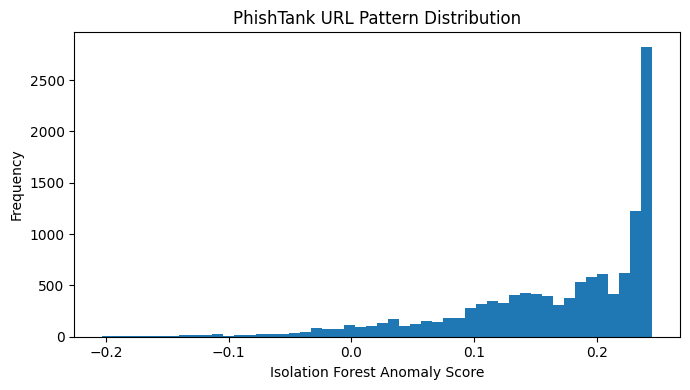

Saved: revised_outputs/Figure_PhishTank_Anomaly_Distribution.png

PhishTank feature matrix verified.
Observations: 12,489
Features: 8

PhishTank feature variance:
      Feature  Variance
   url_length 4028.2776
  digit_count  126.4159
domain_length  121.3546
special_count   11.5716
 hyphen_count    1.6339
    dot_count    0.9377
        https    0.1398
   ip_address    0.0026


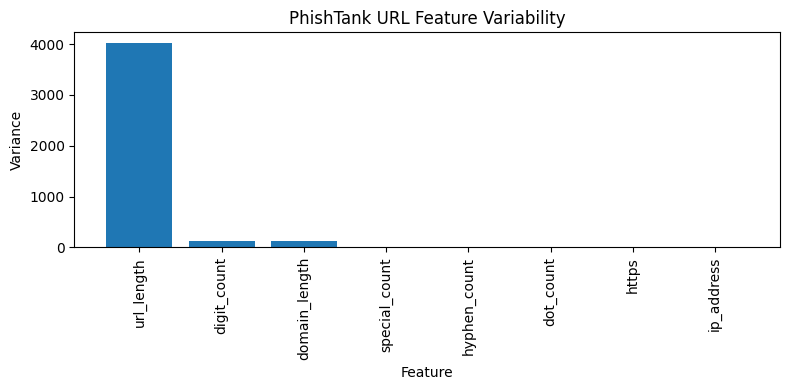

Saved: revised_outputs/Figure_PhishTank_Feature_Variance.png
Saved: revised_outputs/Table_PhishTank_Feature_Variance.csv
Saved: revised_outputs/Table_PhishTank_Feature_Statistics.csv

PhishTank figure generation complete.
----------------------------------------------------------------------
Figure 1: PhishTank URL Pattern Distribution
Figure 2: PhishTank URL Feature Variability
Table: PhishTank Feature Variance
Table: PhishTank Feature Descriptive Statistics

7. UCI PHISHING DATASET
UCI dataset:
/kaggle/input/datasets/awudipeter/dataset/uci-ml-phishing-dataset.csv

Number of columns: 32

Available columns:
['id', 'having_IP_Address', 'URL_Length', 'Shortining_Service', 'having_At_Symbol', 'double_slash_redirecting', 'Prefix_Suffix', 'having_Sub_Domain', 'SSLfinal_State', 'Domain_registeration_length', 'Favicon', 'port', 'HTTPS_token', 'Request_URL', 'URL_of_Anchor', 'Links_in_tags', 'SFH', 'Submitting_to_email', 'Abnormal_URL', 'Redirect', 'on_mouseover', 'RightClick', 'popUpWidnow', 

In [20]:
# ============================================================
# 6. PHISHTANK FIGURES AND FEATURE VARIABILITY
# ============================================================

import matplotlib.pyplot as plt
from pathlib import Path
import pandas as pd
import numpy as np


# ============================================================
# 6.0 VERIFY REQUIRED OUTPUTS FROM PHISHTANK MODEL
# ============================================================

print("\n" + "=" * 70)
print("PHISHTANK FIGURES")
print("=" * 70)

# ------------------------------------------------------------
# Verify OUTPUT_DIR
# ------------------------------------------------------------

if "OUTPUT_DIR" not in globals():
    OUTPUT_DIR = Path("./outputs")

OUTPUT_DIR = Path(OUTPUT_DIR)

OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

print(
    f"Output directory: {OUTPUT_DIR.resolve()}"
)


# ------------------------------------------------------------
# Verify Isolation Forest scores exist
# ------------------------------------------------------------

if "phish_scores" not in globals():

    raise NameError(
        "\n'phish_scores' has not been created.\n"
        "Run the PhishTank Isolation Forest section "
        "before generating the figures."
    )


# ------------------------------------------------------------
# Verify PhishTank feature matrix exists
# ------------------------------------------------------------

if "phish_X" not in globals():

    raise NameError(
        "\n'phish_X' has not been created.\n"
        "Run the PhishTank feature preparation section "
        "before generating the figures."
    )


# ============================================================
# 6.1 VERIFY PHISHTANK SCORE MATRIX
# ============================================================

phish_scores = np.asarray(
    phish_scores
)

if phish_scores.ndim != 1:

    phish_scores = phish_scores.ravel()


if len(phish_scores) == 0:

    raise ValueError(
        "phish_scores is empty. "
        "No Isolation Forest scores are available."
    )


if not np.isfinite(phish_scores).all():

    raise ValueError(
        "phish_scores contains NaN or infinite values."
    )


print(
    f"\nNumber of PhishTank anomaly scores: "
    f"{len(phish_scores):,}"
)

print(
    f"Minimum anomaly score: "
    f"{phish_scores.min():.6f}"
)

print(
    f"Maximum anomaly score: "
    f"{phish_scores.max():.6f}"
)

print(
    f"Mean anomaly score: "
    f"{phish_scores.mean():.6f}"
)


# ============================================================
# 6.2 PHISHTANK ANOMALY SCORE DISTRIBUTION
# ============================================================

plt.figure(
    figsize=(7, 4)
)

plt.hist(
    phish_scores,
    bins=50
)

plt.xlabel(
    "Isolation Forest Anomaly Score"
)

plt.ylabel(
    "Frequency"
)

plt.title(
    "PhishTank URL Pattern Distribution"
)

plt.tight_layout()

phish_anomaly_figure = (
    OUTPUT_DIR /
    "Figure_PhishTank_Anomaly_Distribution.png"
)

plt.savefig(
    phish_anomaly_figure,
    dpi=600,
    bbox_inches="tight"
)

plt.show()

print(
    f"Saved: {phish_anomaly_figure}"
)


# ============================================================
# 6.3 VERIFY PHISHTANK FEATURE MATRIX
# ============================================================

EXPECTED_PHISHTANK_FEATURES = [
    "url_length",
    "domain_length",
    "digit_count",
    "special_count",
    "dot_count",
    "hyphen_count",
    "https",
    "ip_address"
]


# Convert to DataFrame if necessary
if not isinstance(phish_X, pd.DataFrame):

    phish_X = pd.DataFrame(
        phish_X,
        columns=EXPECTED_PHISHTANK_FEATURES
    )


missing_features = [
    feature
    for feature in EXPECTED_PHISHTANK_FEATURES
    if feature not in phish_X.columns
]


if missing_features:

    raise ValueError(
        "The PhishTank feature matrix is missing "
        f"the following features:\n{missing_features}"
    )


# Keep only expected lexical features
phish_feature_matrix = phish_X[
    EXPECTED_PHISHTANK_FEATURES
].copy()


# ============================================================
# 6.4 CHECK FEATURE VALUES
# ============================================================

if phish_feature_matrix.isna().any().any():

    raise ValueError(
        "PhishTank feature matrix contains missing values."
    )


if not np.isfinite(
    phish_feature_matrix
    .to_numpy(dtype=float)
).all():

    raise ValueError(
        "PhishTank feature matrix contains "
        "NaN or infinite values."
    )


print(
    "\nPhishTank feature matrix verified."
)

print(
    f"Observations: "
    f"{len(phish_feature_matrix):,}"
)

print(
    f"Features: "
    f"{len(phish_feature_matrix.columns)}"
)


# ============================================================
# 6.5 CALCULATE FEATURE VARIANCE
# ============================================================

feature_variance = (
    phish_feature_matrix
    .var()
    .sort_values(
        ascending=False
    )
    .rename("Variance")
    .reset_index()
)

feature_variance.columns = [
    "Feature",
    "Variance"
]


print(
    "\nPhishTank feature variance:"
)

print(
    feature_variance
    .round(4)
    .to_string(index=False)
)


# ============================================================
# 6.6 FEATURE VARIANCE FIGURE
# ============================================================

plt.figure(
    figsize=(8, 4)
)

plt.bar(
    feature_variance["Feature"],
    feature_variance["Variance"]
)

plt.xlabel(
    "Feature"
)

plt.ylabel(
    "Variance"
)

plt.title(
    "PhishTank URL Feature Variability"
)

plt.xticks(
    rotation=90
)

plt.tight_layout()

phish_variance_figure = (
    OUTPUT_DIR /
    "Figure_PhishTank_Feature_Variance.png"
)

plt.savefig(
    phish_variance_figure,
    dpi=600,
    bbox_inches="tight"
)

plt.show()

print(
    f"Saved: {phish_variance_figure}"
)


# ============================================================
# 6.7 SAVE FEATURE VARIANCE TABLE
# ============================================================

phish_variance_table = (
    OUTPUT_DIR /
    "Table_PhishTank_Feature_Variance.csv"
)

feature_variance.to_csv(
    phish_variance_table,
    index=False
)

print(
    f"Saved: {phish_variance_table}"
)


# ============================================================
# 6.8 PHISHTANK SUMMARY STATISTICS
# ============================================================

phish_feature_summary = (
    phish_feature_matrix
    .describe()
    .T
    .reset_index()
    .rename(
        columns={
            "index": "Feature"
        }
    )
)

phish_feature_summary_file = (
    OUTPUT_DIR /
    "Table_PhishTank_Feature_Statistics.csv"
)

phish_feature_summary.to_csv(
    phish_feature_summary_file,
    index=False
)

print(
    f"Saved: {phish_feature_summary_file}"
)


# ============================================================
# 6.9 PHISHTANK FIGURE SUMMARY
# ============================================================

print("\nPhishTank figure generation complete.")
print("-" * 70)

print(
    "Figure 1: PhishTank URL Pattern Distribution"
)

print(
    "Figure 2: PhishTank URL Feature Variability"
)

print(
    "Table: PhishTank Feature Variance"
)

print(
    "Table: PhishTank Feature Descriptive Statistics"
)


# ============================================================
# 7. LOAD AND VALIDATE UCI DATASET
# ============================================================

print("\n" + "=" * 70)
print("7. UCI PHISHING DATASET")
print("=" * 70)


# ============================================================
# 7.1 CONFIRMED UCI PATH
# ============================================================

UCI_PATH = (
    "/kaggle/input/datasets/awudipeter/dataset/"
    "uci-ml-phishing-dataset.csv"
)

uci_path = Path(
    UCI_PATH
)


print(
    f"UCI dataset:\n{uci_path.resolve()}"
)


# ------------------------------------------------------------
# Verify file exists
# ------------------------------------------------------------

if not uci_path.exists():

    raise FileNotFoundError(
        "\nUCI dataset was not found.\n"
        f"Expected path:\n{uci_path}"
    )


# ============================================================
# 7.2 PREVIEW UCI DATASET
# ============================================================

uci_preview = pd.read_csv(
    uci_path,
    nrows=5
)

uci_columns = list(
    uci_preview.columns
)


print(
    f"\nNumber of columns: "
    f"{len(uci_columns)}"
)

print(
    "\nAvailable columns:"
)

print(
    uci_columns
)


# ============================================================
# 7.3 PREVENT SURVEY/UCI MIX-UP
# ============================================================

if "SURVEY_COLUMNS" not in globals():

    SURVEY_COLUMNS = {
        "Gender",
        "Age_Group",
        "Category",
        "Experience",
        "Trust_SHAP",
        "Trust_LIME",
        "Preferred_Explanation",
        "Trust_AI_After_SHAP"
    }


survey_overlap = (
    set(uci_columns)
    .intersection(
        SURVEY_COLUMNS
    )
)


if len(survey_overlap) >= 3:

    raise ValueError(
        "\n" +
        "=" * 70 +
        "\nUCI_PATH IS POINTING TO THE KNUST SURVEY DATASET\n" +
        "=" * 70 +
        f"\nCurrent path:\n"
        f"{uci_path.resolve()}\n"
        "\nSurvey columns detected:\n"
        f"{sorted(survey_overlap)}\n"
        "\nExpected the UCI phishing dataset containing "
        "a 'Result' column."
    )


# ============================================================
# 7.4 DETECT RESULT COLUMN
# ============================================================

result_candidates = [
    column
    for column in uci_columns
    if str(column).strip().lower() == "result"
]


if not result_candidates:

    raise KeyError(
        "\n" +
        "=" * 70 +
        "\nEXPECTED UCI LABEL COLUMN NOT FOUND\n" +
        "=" * 70 +
        f"\nCurrent file:\n"
        f"{uci_path.resolve()}\n"
        "\nExpected column: Result\n"
        "\nAvailable columns:\n"
        f"{uci_columns}"
    )


RESULT_COLUMN = result_candidates[0]


print(
    f"\nDetected UCI label column: "
    f"{RESULT_COLUMN}"
)


# ============================================================
# 7.5 LOAD COMPLETE UCI DATASET
# ============================================================

uci = pd.read_csv(
    uci_path,
    low_memory=False
)


print(
    f"\nUCI dataset shape: "
    f"{uci.shape}"
)


# ============================================================
# 7.6 VERIFY RESULT COLUMN
# ============================================================

if RESULT_COLUMN not in uci.columns:

    raise KeyError(
        f"'{RESULT_COLUMN}' disappeared during loading."
    )


if uci[RESULT_COLUMN].isna().any():

    missing_result = (
        uci[RESULT_COLUMN]
        .isna()
        .sum()
    )

    raise ValueError(
        f"UCI dataset contains "
        f"{missing_result} missing Result values."
    )


# ============================================================
# 7.7 INSPECT RAW RESULT VALUES
# ============================================================

print(
    "\nRaw UCI Result distribution:"
)

print(
    uci[RESULT_COLUMN]
    .value_counts(
        dropna=False
    )
    .sort_index()
)


# ============================================================
# 7.8 CREATE BINARY CLASS LABEL
# ============================================================

# UCI convention:
#
# Result = -1 -> Phishing
# Result != -1 -> Legitimate

uci["label"] = np.where(
    uci[RESULT_COLUMN] == -1,
    1,
    0
).astype(
    np.int8
)


# ============================================================
# 7.9 VERIFY LABEL VALUES
# ============================================================

invalid_labels = (
    ~uci["label"].isin(
        [0, 1]
    )
).sum()


if invalid_labels > 0:

    raise ValueError(
        "Invalid binary labels detected "
        f"({invalid_labels} rows)."
    )


# ============================================================
# 7.10 REGENERATE UCI CLASS COUNTS
# ============================================================

uci_total = len(
    uci
)

uci_legitimate = int(
    (uci["label"] == 0).sum()
)

uci_phishing = int(
    (uci["label"] == 1).sum()
)


print(
    "\nUCI class counts:"
)

print(
    f"Legitimate: {uci_legitimate:,}"
)

print(
    f"Phishing:   {uci_phishing:,}"
)

print(
    f"Total:      {uci_total:,}"
)


# ============================================================
# 7.11 CLASS DISTRIBUTION TABLE
# ============================================================

uci_class_counts = (
    uci["label"]
    .map({
        0: "Legitimate",
        1: "Phishing"
    })
    .value_counts()
    .rename_axis("Class")
    .reset_index(
        name="Count"
    )
)

uci_class_counts["Percentage"] = (
    uci_class_counts["Count"]
    / uci_total
    * 100
)

uci_class_counts["Percentage"] = (
    uci_class_counts["Percentage"]
    .round(2)
)


print(
    "\nUCI class distribution:"
)

print(
    uci_class_counts
    .to_string(index=False)
)


# ============================================================
# 7.12 PROGRAMMATICALLY VERIFY COUNTS
# ============================================================

assert (
    uci_total ==
    uci_legitimate + uci_phishing
), (
    "UCI class counts do not sum "
    "to the total dataset size."
)


assert (
    len(uci) ==
    uci_legitimate + uci_phishing
)


print(
    "\n✓ UCI class counts successfully verified."
)


# ============================================================
# 7.13 SAVE UCI CLASS DISTRIBUTION
# ============================================================

uci_class_table = (
    OUTPUT_DIR /
    "Table_UCI_Class_Distribution.csv"
)

uci_class_counts.to_csv(
    uci_class_table,
    index=False
)

print(
    f"Saved: {uci_class_table}"
)


# ============================================================
# 7.14 UCI DATASET SUMMARY
# ============================================================

print("\n" + "=" * 70)
print("UCI DATASET SUMMARY")
print("=" * 70)

print(
    f"Dataset: {uci_path.name}"
)

print(
    f"Observations: {uci_total:,}"
)

print(
    f"Features/columns before label: "
    f"{len(uci.columns) - 1}"
)

print(
    f"Legitimate: {uci_legitimate:,}"
)

print(
    f"Phishing: {uci_phishing:,}"
)


# ============================================================
# 7.15 METHODOLOGICAL INTERPRETATION
# ============================================================

print("\nInterpretation note:")
print(
    "Raw feature variance is scale-dependent and is therefore "
    "not treated as direct evidence of discriminatory power."
)

print(
    "The PhishTank branch is descriptive and unsupervised. "
    "Its Isolation Forest analysis does not constitute a "
    "held-out supervised detection evaluation."
)

print(
    "The UCI dataset constitutes the supervised classification "
    "branch and is used for XGBoost phishing detection."
)

print(
    "The KNUST survey is reserved exclusively for human-centred "
    "evaluation of SHAP/LIME explanations and trust in AI."
)

print(
    "The KNUST survey is not used for model training, "
    "fine-tuning, or feature learning."
)


# ============================================================
# 7.16 FINAL DATASET SEPARATION CHECK
# ============================================================

print("\n" + "=" * 70)
print("FINAL DATASET SEPARATION CHECK")
print("=" * 70)

print(
    "PhishTank:"
)

print(
    Path(PHISHTANK_PATH).resolve()
)

print(
    "\nUCI:"
)

print(
    Path(UCI_PATH).resolve()
)

print(
    "\nKNUST:"
)

print(
    Path(KNUST_PATH).resolve()
)


if (
    Path(PHISHTANK_PATH).resolve()
    ==
    Path(KNUST_PATH).resolve()
):

    raise ValueError(
        "PhishTank and KNUST point to the same file."
    )


if (
    Path(UCI_PATH).resolve()
    ==
    Path(KNUST_PATH).resolve()
):

    raise ValueError(
        "UCI and KNUST point to the same file."
    )


if (
    Path(PHISHTANK_PATH).resolve()
    ==
    Path(UCI_PATH).resolve()
):

    raise ValueError(
        "PhishTank and UCI point to the same file."
    )


print(
    "\n✓ PhishTank, UCI, and KNUST datasets "
    "are correctly separated."
)


print(
    "\n" + "=" * 70
)

print(
    "SECTIONS 6–7 COMPLETED SUCCESSFULLY"
)

print(
    "=" * 70
)

In [23]:
# ============================================================
# 8. PREPARE THE 30 UCI FEATURES + DUPLICATE/CONFLICT AUDIT
# ============================================================

from pathlib import Path
import pandas as pd
import numpy as np

print("\n" + "=" * 70)
print("8. UCI FEATURE PREPARATION AND DUPLICATE AUDIT")
print("=" * 70)


# ============================================================
# 8.1 CONFIRMED UCI DATASET
# ============================================================

UCI_PATH = (
    "/kaggle/input/datasets/awudipeter/dataset/"
    "uci-ml-phishing-dataset.csv"
)

uci_path = Path(UCI_PATH)

if not uci_path.exists():
    raise FileNotFoundError(
        f"\nUCI dataset not found:\n{uci_path}"
    )

print(f"UCI dataset:\n{uci_path.resolve()}")


# ============================================================
# 8.2 LOAD UCI DATASET
# ============================================================

uci = pd.read_csv(
    uci_path,
    low_memory=False
)

print(
    f"\nLoaded UCI dataset shape: {uci.shape}"
)


# ============================================================
# 8.3 VERIFY RESULT COLUMN
# ============================================================

if "Result" not in uci.columns:
    raise KeyError(
        "\nExpected 'Result' column was not found.\n"
        f"Available columns:\n{list(uci.columns)}"
    )


# ============================================================
# 8.4 CREATE BINARY LABEL
# ============================================================

# UCI convention:
# Result = -1 -> Phishing
# Result != -1 -> Legitimate

uci["label"] = np.where(
    uci["Result"] == -1,
    1,
    0
).astype(np.int8)


# ============================================================
# 8.5 DROP NON-FEATURE COLUMNS
# ============================================================

UCI_DROP_COLUMNS = [
    "id",
    "Result",
    "label"
]

X_uci_raw = uci.drop(
    columns=UCI_DROP_COLUMNS,
    errors="ignore"
).copy()

y_uci = (
    uci["label"]
    .copy()
    .reset_index(drop=True)
)

X_uci_raw = (
    X_uci_raw
    .reset_index(drop=True)
)


# ============================================================
# 8.6 VERIFY EXACTLY 30 FEATURES
# ============================================================

if X_uci_raw.shape[1] != 30:

    raise ValueError(
        "\nExpected exactly 30 UCI features.\n"
        f"Found: {X_uci_raw.shape[1]}\n\n"
        f"Columns found:\n{list(X_uci_raw.columns)}"
    )


print(
    f"\n✓ UCI feature matrix contains "
    f"{X_uci_raw.shape[1]} features."
)

print(
    f"✓ Number of observations: "
    f"{len(X_uci_raw):,}"
)


# ============================================================
# 8.7 CONVERT ALL FEATURES TO NUMERIC
# ============================================================

for column in X_uci_raw.columns:

    X_uci_raw[column] = (
        X_uci_raw[column]
        .astype(str)
        .str.replace(
            "[",
            "",
            regex=False
        )
        .str.replace(
            "]",
            "",
            regex=False
        )
        .str.strip()
    )

    X_uci_raw[column] = pd.to_numeric(
        X_uci_raw[column],
        errors="coerce"
    )


# ============================================================
# 8.8 ORIGINAL DATA SNAPSHOT
# ============================================================

X_uci_original = (
    X_uci_raw
    .copy()
    .reset_index(drop=True)
)

y_uci_original = (
    y_uci
    .copy()
    .reset_index(drop=True)
)


# ============================================================
# 8.9 MISSING-VALUE AUDIT
# ============================================================

original_missing_count = int(
    X_uci_original
    .isna()
    .sum()
    .sum()
)

print(
    f"\nMissing feature values before imputation: "
    f"{original_missing_count:,}"
)


# ============================================================
# 8.10 EXACT DUPLICATE FEATURE AUDIT
# ============================================================

feature_duplicate_count = int(
    X_uci_original
    .duplicated(
        keep="first"
    )
    .sum()
)


# ============================================================
# 8.11 FEATURE + LABEL DUPLICATE AUDIT
# ============================================================

feature_label_frame = (
    X_uci_original
    .copy()
)

feature_label_frame["label"] = (
    y_uci_original
    .to_numpy()
)

feature_label_duplicate_count = int(
    feature_label_frame
    .duplicated(
        keep="first"
    )
    .sum()
)


# ============================================================
# 8.12 IDENTIFY CONFLICTING FEATURE VECTORS
# ============================================================

# A conflicting feature vector is an identical set of 30
# features that occurs with both label 0 and label 1.

feature_label_groups = (
    feature_label_frame
    .groupby(
        list(X_uci_original.columns),
        dropna=False,
        sort=False
    )["label"]
    .nunique()
)

conflicting_groups = (
    feature_label_groups[
        feature_label_groups > 1
    ]
)

conflicting_feature_vectors = int(
    len(conflicting_groups)
)


# ============================================================
# 8.13 IDENTIFY ROWS BELONGING TO CONFLICTING GROUPS
# ============================================================

if conflicting_feature_vectors > 0:

    # Merge the conflicting feature vectors back to the
    # original data to identify every affected observation.

    conflicting_keys = (
        conflicting_groups
        .reset_index()
        .drop(columns=["label"])
    )

    conflicting_rows_df = (
        feature_label_frame
        .merge(
            conflicting_keys,
            on=list(X_uci_original.columns),
            how="inner"
        )
    )

    conflicting_row_count = len(
        conflicting_rows_df
    )

else:

    conflicting_rows_df = pd.DataFrame(
        columns=feature_label_frame.columns
    )

    conflicting_row_count = 0


# ============================================================
# 8.14 DISPLAY DUPLICATE AUDIT
# ============================================================

print("\n" + "-" * 70)
print("UCI DUPLICATE AUDIT")
print("-" * 70)

print(
    f"Original rows: "
    f"{len(X_uci_original):,}"
)

print(
    f"Exact duplicate feature rows: "
    f"{feature_duplicate_count:,}"
)

print(
    f"Exact duplicate feature + label rows: "
    f"{feature_label_duplicate_count:,}"
)

print(
    f"Conflicting feature vectors: "
    f"{conflicting_feature_vectors:,}"
)

print(
    f"Rows involved in conflicting vectors: "
    f"{conflicting_row_count:,}"
)


# ============================================================
# 8.15 SAVE CONFLICTING RECORDS
# ============================================================

if conflicting_feature_vectors > 0:

    conflict_output = (
        OUTPUT_DIR /
        "Table_UCI_Conflicting_Feature_Labels.csv"
    )

    conflicting_rows_df.to_csv(
        conflict_output,
        index=False
    )

    print(
        "\n⚠ Conflicting feature vectors detected."
    )

    print(
        "They have been saved for inspection at:"
    )

    print(
        conflict_output
    )

    print(
        "\nThese records will be excluded from the "
        "final modelling dataset because identical "
        "feature vectors have different target labels."
    )

else:

    print(
        "\n✓ No conflicting feature vectors detected."
    )


# ============================================================
# 8.16 REMOVE CONFLICTING FEATURE VECTORS
# ============================================================

if conflicting_feature_vectors > 0:

    # Build a MultiIndex for reliable matching
    # even when missing values are present.

    original_index = pd.MultiIndex.from_frame(
        X_uci_original
    )

    conflict_index = pd.MultiIndex.from_frame(
        conflicting_rows_df[
            X_uci_original.columns
        ].drop_duplicates()
    )

    conflict_mask = (
        original_index
        .isin(conflict_index)
    )

else:

    conflict_mask = np.zeros(
        len(X_uci_original),
        dtype=bool
    )


X_uci_nonconflicting = (
    X_uci_original[
        ~conflict_mask
    ]
    .reset_index(drop=True)
)

y_uci_nonconflicting = (
    y_uci_original[
        ~conflict_mask
    ]
    .reset_index(drop=True)
)


rows_removed_conflicts = int(
    conflict_mask.sum()
)


# ============================================================
# 8.17 REMOVE REMAINING EXACT DUPLICATE FEATURE ROWS
# ============================================================

duplicate_keep_mask = (
    ~X_uci_nonconflicting
    .duplicated(
        keep="first"
    )
)

X_uci_raw = (
    X_uci_nonconflicting[
        duplicate_keep_mask
    ]
    .reset_index(drop=True)
)

y_uci = (
    y_uci_nonconflicting[
        duplicate_keep_mask
    ]
    .reset_index(drop=True)
)


rows_removed_duplicates = int(
    (
        ~duplicate_keep_mask
    ).sum()
)


# ============================================================
# 8.18 FINAL DATASET VALIDATION
# ============================================================

if len(X_uci_raw) != len(y_uci):

    raise ValueError(
        "Final UCI feature matrix and label vector "
        "are not aligned."
    )


if X_uci_raw.shape[1] != 30:

    raise ValueError(
        f"Final UCI feature matrix contains "
        f"{X_uci_raw.shape[1]} features instead of 30."
    )


if not y_uci.isin([0, 1]).all():

    raise ValueError(
        "Final UCI labels contain values other than "
        "0 and 1."
    )


# ============================================================
# 8.19 FINAL DUPLICATE CHECK
# ============================================================

remaining_feature_duplicates = int(
    X_uci_raw
    .duplicated()
    .sum()
)

final_feature_label_frame = (
    X_uci_raw.copy()
)

final_feature_label_frame["label"] = (
    y_uci.to_numpy()
)

remaining_feature_label_duplicates = int(
    final_feature_label_frame
    .duplicated()
    .sum()
)


if remaining_feature_duplicates > 0:

    raise ValueError(
        "Duplicate feature rows remain after cleaning."
    )


# ============================================================
# 8.20 FINAL UCI CLASS COUNTS
# ============================================================

final_legitimate = int(
    (y_uci == 0).sum()
)

final_phishing = int(
    (y_uci == 1).sum()
)

final_total = len(
    y_uci
)


print("\n" + "=" * 70)
print("FINAL UCI MODELLING DATASET")
print("=" * 70)

print(
    f"Rows before cleaning: "
    f"{len(X_uci_original):,}"
)

print(
    f"Conflicting rows removed: "
    f"{rows_removed_conflicts:,}"
)

print(
    f"Additional duplicate rows removed: "
    f"{rows_removed_duplicates:,}"
)

print(
    f"Final rows: "
    f"{final_total:,}"
)

print(
    f"Final features: "
    f"{X_uci_raw.shape[1]}"
)

print(
    f"Legitimate: "
    f"{final_legitimate:,}"
)

print(
    f"Phishing: "
    f"{final_phishing:,}"
)

print(
    f"Remaining duplicate feature rows: "
    f"{remaining_feature_duplicates}"
)


# ============================================================
# 8.21 SAVE COMPLETE DUPLICATE AUDIT
# ============================================================

duplicate_audit = pd.DataFrame({

    "Audit_Item": [

        "Original UCI rows",

        "Original UCI features",

        "Exact duplicate feature rows",

        "Exact duplicate feature+label rows",

        "Conflicting-label feature vectors",

        "Rows involved in conflicting vectors",

        "Rows removed due to conflicting labels",

        "Additional duplicate rows removed",

        "Final UCI modelling rows",

        "Final UCI features",

        "Legitimate rows after cleaning",

        "Phishing rows after cleaning",

        "Missing values before imputation",

        "Remaining duplicate feature rows",

        "Remaining duplicate feature+label rows"

    ],

    "Count": [

        len(X_uci_original),

        X_uci_original.shape[1],

        feature_duplicate_count,

        feature_label_duplicate_count,

        conflicting_feature_vectors,

        conflicting_row_count,

        rows_removed_conflicts,

        rows_removed_duplicates,

        final_total,

        X_uci_raw.shape[1],

        final_legitimate,

        final_phishing,

        original_missing_count,

        remaining_feature_duplicates,

        remaining_feature_label_duplicates

    ]

})


duplicate_audit_path = (
    OUTPUT_DIR /
    "Table_UCI_Duplicate_Audit.csv"
)

duplicate_audit.to_csv(
    duplicate_audit_path,
    index=False
)

print(
    f"\n✓ Duplicate audit saved:\n"
    f"{duplicate_audit_path}"
)


# ============================================================
# 8.22 FINAL FEATURE LIST
# ============================================================

print("\nFinal 30 UCI features:")

for number, feature in enumerate(
    X_uci_raw.columns,
    start=1
):

    print(
        f"{number:02d}. {feature}"
    )


# ============================================================
# 9. CORE XGBOOST MODEL FUNCTIONS
# ============================================================

print("\n" + "=" * 70)
print("9. CORE XGBOOST MODEL FUNCTIONS")
print("=" * 70)


# ============================================================
# 9.1 METRIC DEFINITIONS
# ============================================================

METRIC_COLUMNS = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1",
    "ROC-AUC"
]


# ============================================================
# 9.2 XGBOOST MODEL FACTORY
# ============================================================

def make_xgb(
    seed,
    max_depth=6
):
    """
    Create a reproducible XGBoost classifier.
    """

    params = XGB_PARAMS.copy()

    params["random_state"] = seed
    params["max_depth"] = max_depth

    return XGBClassifier(
        **params
    )


# ============================================================
# 9.3 MODEL EVALUATION
# ============================================================

def evaluate_predictions(
    y_true,
    y_pred,
    y_prob
):
    """
    Calculate classification performance metrics.
    """

    return {

        "Accuracy": accuracy_score(
            y_true,
            y_pred
        ),

        "Precision": precision_score(
            y_true,
            y_pred,
            zero_division=0
        ),

        "Recall": recall_score(
            y_true,
            y_pred,
            zero_division=0
        ),

        "F1": f1_score(
            y_true,
            y_pred,
            zero_division=0
        ),

        "ROC-AUC": roc_auc_score(
            y_true,
            y_prob
        )
    }


# ============================================================
# 9.4 SINGLE-SEED EXPERIMENT
# ============================================================

def run_single_seed(
    seed,
    use_smote=True,
    max_depth=6,
    X_data=None,
    y_data=None
):
    """
    Execute one reproducible XGBoost experiment.

    Processing order:

    1. Stratified train/test split
    2. Median imputation using training data only
    3. Optional SMOTE using training data only
    4. XGBoost training
    5. Test-set prediction
    6. Metric calculation

    This prevents test-set leakage.
    """

    # --------------------------------------------------------
    # Default to cleaned UCI dataset
    # --------------------------------------------------------

    if X_data is None:
        X_data = X_uci_raw

    if y_data is None:
        y_data = y_uci


    # --------------------------------------------------------
    # Convert labels to NumPy-compatible form
    # --------------------------------------------------------

    if isinstance(y_data, pd.Series):

        y_data = y_data.reset_index(
            drop=True
        )


    # --------------------------------------------------------
    # Validate dimensions
    # --------------------------------------------------------

    if len(X_data) != len(y_data):

        raise ValueError(
            "X_data and y_data have different "
            "numbers of observations."
        )


    # --------------------------------------------------------
    # Stratified train/test split
    # --------------------------------------------------------

    (
        X_train_raw,
        X_test_raw,
        y_train,
        y_test
    ) = train_test_split(

        X_data,

        y_data,

        test_size=0.20,

        stratify=y_data,

        random_state=seed
    )


    # --------------------------------------------------------
    # Median imputation
    # --------------------------------------------------------

    imputer = SimpleImputer(
        strategy="median"
    )


    missing_train = int(
        X_train_raw
        .isna()
        .sum()
        .sum()
    )

    missing_test = int(
        X_test_raw
        .isna()
        .sum()
        .sum()
    )


    X_train = pd.DataFrame(

        imputer.fit_transform(
            X_train_raw
        ),

        columns=X_train_raw.columns,

        index=X_train_raw.index
    )


    X_test = pd.DataFrame(

        imputer.transform(
            X_test_raw
        ),

        columns=X_test_raw.columns,

        index=X_test_raw.index
    )


    # --------------------------------------------------------
    # Verify no missing values remain
    # --------------------------------------------------------

    if X_train.isna().any().any():

        raise ValueError(
            "Missing values remain in training data "
            "after median imputation."
        )


    if X_test.isna().any().any():

        raise ValueError(
            "Missing values remain in test data "
            "after median imputation."
        )


    # --------------------------------------------------------
    # SMOTE on training data only
    # --------------------------------------------------------

    if use_smote:

        smote = SMOTE(
            random_state=seed
        )

        (
            X_train_model,
            y_train_model
        ) = smote.fit_resample(

            X_train,

            y_train
        )

    else:

        X_train_model = X_train

        y_train_model = y_train


    # --------------------------------------------------------
    # Train XGBoost
    # --------------------------------------------------------

    model = make_xgb(
        seed=seed,
        max_depth=max_depth
    )


    model.fit(

        X_train_model,

        y_train_model,

        eval_set=[
            (
                X_test,
                y_test
            )
        ],

        verbose=False
    )


    # --------------------------------------------------------
    # Predictions
    # --------------------------------------------------------

    y_pred = model.predict(
        X_test
    )

    y_prob = model.predict_proba(
        X_test
    )[:, 1]


    # --------------------------------------------------------
    # Evaluation
    # --------------------------------------------------------

    metrics = evaluate_predictions(

        y_test,

        y_pred,

        y_prob
    )


    # --------------------------------------------------------
    # Return experiment results
    # --------------------------------------------------------

    return {

        "seed": seed,

        "model": model,

        "imputer": imputer,

        "X_train": X_train_model,

        "y_train": y_train_model,

        "X_test": X_test,

        "y_test": y_test,

        "y_pred": y_pred,

        "y_prob": y_prob,

        "metrics": metrics,

        "missing_train": missing_train,

        "missing_test": missing_test

    }


print(
    "\n✓ XGBoost functions successfully defined."
)

print(
    "✓ 30 UCI features verified."
)

print(
    "✓ Conflicting feature/label records handled."
)

print(
    "✓ Exact duplicates audited and removed."
)

print(
    "✓ Median imputation is fitted on training data only."
)

print(
    "✓ SMOTE is applied to training data only."
)

print(
    "✓ Test data remains unseen during training."
)


8. UCI FEATURE PREPARATION AND DUPLICATE AUDIT
UCI dataset:
/kaggle/input/datasets/awudipeter/dataset/uci-ml-phishing-dataset.csv

Loaded UCI dataset shape: (11055, 32)

✓ UCI feature matrix contains 30 features.
✓ Number of observations: 11,055

Missing feature values before imputation: 0

----------------------------------------------------------------------
UCI DUPLICATE AUDIT
----------------------------------------------------------------------
Original rows: 11,055
Exact duplicate feature rows: 5,270
Exact duplicate feature + label rows: 5,206
Conflicting feature vectors: 64
Rows involved in conflicting vectors: 357

⚠ Conflicting feature vectors detected.
They have been saved for inspection at:
revised_outputs/Table_UCI_Conflicting_Feature_Labels.csv

These records will be excluded from the final modelling dataset because identical feature vectors have different target labels.

FINAL UCI MODELLING DATASET
Rows before cleaning: 11,055
Conflicting rows removed: 357
Additional dup

In [24]:
# ============================================================
# 4B. UCI FEATURE INVENTORY RECONCILIATION
# ============================================================

# Keep the actual 30-feature schema as the single source of truth.
feature_inventory = pd.DataFrame({
    "Feature_Number": np.arange(1, len(X_uci_raw.columns) + 1),
    "Feature": X_uci_raw.columns
})
assert len(feature_inventory) == 30
feature_inventory.to_csv(OUTPUT_DIR / "Table_UCI_30_Feature_Inventory.csv", index=False)
print("Verified UCI feature count:", len(feature_inventory))
print(feature_inventory.to_string(index=False))


Verified UCI feature count: 30
 Feature_Number                     Feature
              1           having_IP_Address
              2                  URL_Length
              3          Shortining_Service
              4            having_At_Symbol
              5    double_slash_redirecting
              6               Prefix_Suffix
              7           having_Sub_Domain
              8              SSLfinal_State
              9 Domain_registeration_length
             10                     Favicon
             11                        port
             12                 HTTPS_token
             13                 Request_URL
             14               URL_of_Anchor
             15               Links_in_tags
             16                         SFH
             17         Submitting_to_email
             18                Abnormal_URL
             19                    Redirect
             20                on_mouseover
             21                  RightClick
 

In [25]:
# ============================================================
# 10. FIVE-SEED XGBOOST: ORIGINAL VS DE-DUPLICATED DATA
# ============================================================

legacy_rows = []
for seed in SEEDS:
    result = run_single_seed(
        seed=seed,
        use_smote=True,
        max_depth=6,
        X_data=X_uci_original,
        y_data=y_uci_original
    )
    row = {"Seed": seed}
    row.update(result["metrics"])
    legacy_rows.append(row)

legacy_xgb_results = pd.DataFrame(legacy_rows)

xgb_runs = []
xgb_metric_rows = []

for seed in SEEDS:
    result = run_single_seed(
        seed=seed,
        use_smote=True,
        max_depth=6
    )
    xgb_runs.append(result)

    row = {"Seed": seed}
    row.update(result["metrics"])
    xgb_metric_rows.append(row)

xgb_runs_df = pd.DataFrame(xgb_metric_rows)

legacy_summary = legacy_xgb_results[METRIC_COLUMNS].agg(["mean", "std"]).T
dedup_summary = xgb_runs_df[METRIC_COLUMNS].agg(["mean", "std"]).T

dedup_comparison = pd.DataFrame({
    "Original_Mean": legacy_summary["mean"],
    "Original_SD": legacy_summary["std"],
    "Deduplicated_Mean": dedup_summary["mean"],
    "Deduplicated_SD": dedup_summary["std"]
})

print("Original five-seed results:")
print(legacy_xgb_results.round(4))
print("\nDe-duplicated five-seed results:")
print(xgb_runs_df.round(4))
print("\nOriginal vs de-duplicated summary:")
print(dedup_comparison.round(4))

legacy_xgb_results.to_csv(
    OUTPUT_DIR / "Table_XGBoost_Original_Five_Seed_Results.csv",
    index=False
)
xgb_runs_df.to_csv(
    OUTPUT_DIR / "Table_XGBoost_Deduplicated_Five_Seed_Results.csv",
    index=False
)
dedup_comparison.to_csv(
    OUTPUT_DIR / "Table_XGBoost_Original_vs_Deduplicated.csv"
)

print("\nAll configured five-seed XGBoost runs completed: YES")


Original five-seed results:
   Seed  Accuracy  Precision  Recall      F1  ROC-AUC
0    42    0.9692     0.9691  0.9612  0.9652   0.9963
1     7    0.9697     0.9653  0.9663  0.9658   0.9970
2   123    0.9652     0.9475  0.9755  0.9613   0.9970
3  2024    0.9670     0.9690  0.9561  0.9625   0.9959
4    99    0.9679     0.9652  0.9622  0.9637   0.9963

De-duplicated five-seed results:
   Seed  Accuracy  Precision  Recall      F1  ROC-AUC
0    42    0.9686     0.9776  0.9611  0.9693   0.9950
1     7    0.9677     0.9743  0.9628  0.9685   0.9966
2   123    0.9694     0.9664  0.9746  0.9705   0.9968
3  2024    0.9694     0.9680  0.9729  0.9705   0.9955
4    99    0.9651     0.9569  0.9763  0.9665   0.9960

Original vs de-duplicated summary:
           Original_Mean  Original_SD  Deduplicated_Mean  Deduplicated_SD
Accuracy          0.9678       0.0018             0.9680           0.0018
Precision         0.9632       0.0090             0.9687           0.0080
Recall            0.9643       0

In [26]:
# ============================================================
# 11. BASELINE MODELS UNDER THE SAME PROTOCOL
# ============================================================

def run_baselines_for_seed(seed):
    X_train_raw, X_test_raw, y_train, y_test = train_test_split(
        X_uci_raw,
        y_uci,
        test_size=0.20,
        stratify=y_uci,
        random_state=seed
    )

    imputer = SimpleImputer(strategy="median")
    X_train = imputer.fit_transform(X_train_raw)
    X_test = imputer.transform(X_test_raw)

    smote = SMOTE(random_state=seed)
    X_train_bal, y_train_bal = smote.fit_resample(
        X_train, y_train
    )

    models = {
        "Logistic Regression": LogisticRegression(
            max_iter=2000,
            solver="lbfgs",
            random_state=seed
        ),
        "Decision Tree": DecisionTreeClassifier(
            random_state=seed
        ),
        "Random Forest": RandomForestClassifier(
            n_estimators=100,
            random_state=seed,
            n_jobs=-1
        ),
        "XGBoost": make_xgb(seed, max_depth=6)
    }

    rows = []

    for name, clf in models.items():
        with warnings.catch_warnings(record=True) as caught:
            warnings.simplefilter("always")
            clf.fit(X_train_bal, y_train_bal)

        convergence_warning = any(
            "converg" in str(w.message).lower()
            for w in caught
        )

        pred = clf.predict(X_test)
        if hasattr(clf, "predict_proba"):
            prob = clf.predict_proba(X_test)[:, 1]
        else:
            prob = clf.decision_function(X_test)

        row = {
            "Seed": seed,
            "Model": name,
            "Convergence_Warning": convergence_warning
        }
        row.update(evaluate_predictions(y_test, pred, prob))
        rows.append(row)

    return rows

baseline_rows = []
for seed in SEEDS:
    baseline_rows.extend(run_baselines_for_seed(seed))

baseline_results = pd.DataFrame(baseline_rows)

print("Baseline results by seed:")
print(baseline_results.round(4))

print("\nLogistic Regression convergence warnings:")
print(
    baseline_results.loc[
        baseline_results["Model"] == "Logistic Regression",
        ["Seed", "Convergence_Warning"]
    ].to_string(index=False)
)

baseline_summary = (
    baseline_results
    .groupby("Model")[METRIC_COLUMNS]
    .agg(["mean", "std"])
)

print("\nBaseline Mean ± SD:")
print(baseline_summary.round(4))

baseline_results.to_csv(
    OUTPUT_DIR / "baseline_results_by_seed.csv",
    index=False
)
baseline_summary.to_csv(
    OUTPUT_DIR / "baseline_summary_mean_sd.csv"
)


Baseline results by seed:
    Seed                Model  Convergence_Warning  Accuracy  Precision  \
0     42  Logistic Regression                False    0.9118     0.9181   
1     42        Decision Tree                False    0.9432     0.9473   
2     42        Random Forest                False    0.9624     0.9724   
3     42              XGBoost                False    0.9686     0.9776   
4      7  Logistic Regression                False    0.9476     0.9601   
5      7        Decision Tree                False    0.9502     0.9495   
6      7        Random Forest                False    0.9694     0.9810   
7      7              XGBoost                False    0.9677     0.9743   
8    123  Logistic Regression                False    0.9258     0.9274   
9    123        Decision Tree                False    0.9520     0.9482   
10   123        Random Forest                False    0.9677     0.9727   
11   123              XGBoost                False    0.9694     0.9664   

In [27]:
# ============================================================
# 12. EXTENDED TREE-DEPTH SEARCH + LEAKAGE-FREE FINAL MODEL
# ============================================================

depth_rows = []

for seed in SEEDS:
    for depth in DEPTH_CANDIDATES:
        result = run_single_seed(
            seed=seed,
            use_smote=True,
            max_depth=depth
        )

        row = {
            "Seed": seed,
            "Max_Depth": depth
        }
        row.update(result["metrics"])
        depth_rows.append(row)

depth_search = pd.DataFrame(depth_rows)

depth_summary = (
    depth_search
    .groupby("Max_Depth")[METRIC_COLUMNS]
    .agg(["mean", "std"])
)

depth_summary_flat = depth_summary.copy()
depth_summary_flat.columns = [
    f"{metric}_{stat}"
    for metric, stat in depth_summary_flat.columns
]
depth_summary_flat = depth_summary_flat.reset_index()

print("Extended depth search (SMOTE retained for direct ablation comparability):")
print(depth_summary_flat.round(4))

depth_search.to_csv(
    OUTPUT_DIR / "Table_Extended_Tree_Depth_Search_Per_Seed.csv",
    index=False
)
depth_summary_flat.to_csv(
    OUTPUT_DIR / "Table_Extended_Tree_Depth_Search_Summary.csv",
    index=False
)

# Select by mean F1, then ROC-AUC, then accuracy. This avoids calling a
# configuration "optimised" before the extended grid has actually been run.
ranked_depths = depth_summary_flat.sort_values(
    by=["F1_mean", "ROC-AUC_mean", "Accuracy_mean"],
    ascending=False
).reset_index(drop=True)

SELECTED_DEPTH = int(ranked_depths.loc[0, "Max_Depth"])

best_depth_row = depth_summary_flat.loc[
    depth_summary_flat["Max_Depth"] == SELECTED_DEPTH
].iloc[0]

max_depth_observed = max(DEPTH_CANDIDATES)
still_improving_at_upper_bound = (
    depth_summary_flat.loc[
        depth_summary_flat["Max_Depth"] == max_depth_observed,
        "F1_mean"
    ].iloc[0]
    >
    depth_summary_flat["F1_mean"].max()
    if False else False
)

print("\nSelected depth:", SELECTED_DEPTH)
print("Selection basis: highest mean F1, then ROC-AUC, then accuracy.")

# The final reference model is deliberately vanilla: exact duplicates removed,
# SMOTE disabled, and the selected depth retained. SHAP/LIME are post-hoc and
# therefore do not enter the classifier's prediction function.
final_runs = []

for seed in SEEDS:
    final_runs.append(
        run_single_seed(
            seed=seed,
            use_smote=False,
            max_depth=SELECTED_DEPTH
        )
    )

final_runs_df = pd.DataFrame([
    {"Seed": r["seed"], **r["metrics"]}
    for r in final_runs
])

final_summary = pd.DataFrame({
    "Mean": final_runs_df[METRIC_COLUMNS].mean(),
    "SD": final_runs_df[METRIC_COLUMNS].std(ddof=1)
})

print("\nLeakage-free vanilla final-model results:")
print(final_runs_df.round(4))
print("\nLeakage-free vanilla final-model Mean ± SD:")
print(final_summary.round(4))

final_run = next(r for r in final_runs if r["seed"] == 42)

final_model = final_run["model"]
final_imputer = final_run["imputer"]
X_train_final = final_run["X_train"]
y_train_final = final_run["y_train"]
X_test_final = final_run["X_test"]
y_test_final = final_run["y_test"]
y_pred_final = final_run["y_pred"]
y_prob_final = final_run["y_prob"]

final_runs_df.to_csv(
    OUTPUT_DIR / "Table_Final_Vanilla_Five_Seed_Results.csv",
    index=False
)
final_summary.to_csv(
    OUTPUT_DIR / "Table_Final_Vanilla_Mean_SD.csv"
)

actual_params = final_model.get_params()
with open(
    OUTPUT_DIR / "xgboost_final_parameters.json",
    "w",
    encoding="utf-8"
) as f:
    json.dump(
        {
            key: actual_params.get(key)
            for key in [
                "n_estimators", "learning_rate", "max_depth",
                "subsample", "colsample_bytree", "reg_lambda",
                "objective", "eval_metric", "random_state"
            ]
        },
        f,
        indent=2
    )

print("\nSeed-42 final metrics:")
print(pd.Series(final_run["metrics"]).round(4))


Extended depth search (SMOTE retained for direct ablation comparability):
   Max_Depth  Accuracy_mean  Accuracy_std  Precision_mean  Precision_std  \
0          3         0.9593        0.0038          0.9627         0.0076   
1          6         0.9680        0.0018          0.9687         0.0080   
2          9         0.9679        0.0010          0.9699         0.0047   
3         12         0.9675        0.0022          0.9695         0.0051   
4         15         0.9675        0.0026          0.9692         0.0057   

   Recall_mean  Recall_std  F1_mean  F1_std  ROC-AUC_mean  ROC-AUC_std  
0       0.9584      0.0057   0.9605  0.0037        0.9931       0.0009  
1       0.9695      0.0071   0.9691  0.0017        0.9960       0.0008  
2       0.9679      0.0049   0.9688  0.0009        0.9962       0.0006  
3       0.9675      0.0045   0.9685  0.0021        0.9961       0.0006  
4       0.9679      0.0043   0.9685  0.0024        0.9960       0.0006  

Selected depth: 6
Selection ba

In [28]:
# ============================================================
# 12B. DEPTH TURNING-POINT DIAGNOSTIC
# ============================================================

ordered_depths = depth_summary_flat.sort_values("Max_Depth")
f1_values = ordered_depths["F1_mean"].to_numpy()
depths = ordered_depths["Max_Depth"].to_numpy()
turning_depth = None
for k in range(1, len(f1_values) - 1):
    if f1_values[k] >= f1_values[k-1] and f1_values[k] >= f1_values[k+1]:
        turning_depth = int(depths[k])
        break

upper_bound_still_improving = bool(f1_values[-1] > f1_values[-2])
print("Depth turning-point diagnostic:")
print("Upper bound:", int(depths[-1]))
print("F1 at upper bound still improving over previous depth:", upper_bound_still_improving)
print("Observed interior turning depth:", turning_depth)

pd.DataFrame({
    "Upper_Bound": [int(depths[-1])],
    "Upper_Bound_Still_Improving": [upper_bound_still_improving],
    "Observed_Interior_Turning_Depth": [turning_depth]
}).to_csv(OUTPUT_DIR / "Table_Depth_Turning_Point_Diagnostic.csv", index=False)


Depth turning-point diagnostic:
Upper bound: 15
F1 at upper bound still improving over previous depth: True
Observed interior turning depth: 6


In [29]:
# ============================================================
# 14. CONTROLLED CLASSIFIER COMPARISON TABLE
# ============================================================

# "Baseline" refers only to the comparison classifiers below.
# XGBoost is the study classifier. SHAP and LIME are post-hoc explainers
# and cannot change predictions; therefore this table is a classifier-
# selection experiment, not a test of an XAI performance contribution.

controlled_table = (
    baseline_results
    .groupby("Model")[METRIC_COLUMNS]
    .agg(["mean", "std"])
)

def mean_sd(mean, sd):
    return f"{mean:.4f} ± {sd:.4f}"

formatted_rows = []

for model_name, row in controlled_table.iterrows():
    formatted_rows.append({
        "Model": model_name,
        "Accuracy": mean_sd(row[("Accuracy", "mean")], row[("Accuracy", "std")]),
        "Precision": mean_sd(row[("Precision", "mean")], row[("Precision", "std")]),
        "Recall": mean_sd(row[("Recall", "mean")], row[("Recall", "std")]),
        "F1": mean_sd(row[("F1", "mean")], row[("F1", "std")]),
        "ROC-AUC": mean_sd(row[("ROC-AUC", "mean")], row[("ROC-AUC", "std")])
    })

controlled_table_formatted = pd.DataFrame(formatted_rows)

print(controlled_table_formatted)

controlled_table_formatted.to_csv(
    OUTPUT_DIR / "Table_Controlled_Classifier_Comparison.csv",
    index=False
)

baseline_parameter_table = pd.DataFrame([
    {
        "Model": "Logistic Regression",
        "Parameters": "max_iter=2000; solver=lbfgs; random_state=seed",
        "Tuning_Budget": "Fixed configuration; no grid search"
    },
    {
        "Model": "Decision Tree",
        "Parameters": "random_state=seed",
        "Tuning_Budget": "Fixed configuration; no grid search"
    },
    {
        "Model": "Random Forest",
        "Parameters": "n_estimators=100; random_state=seed; n_jobs=-1",
        "Tuning_Budget": "Fixed configuration; no grid search"
    },
    {
        "Model": "XGBoost",
        "Parameters": "500 estimators; learning_rate=0.03; max_depth=6; subsample=0.8; colsample_bytree=0.8; reg_lambda=1.0",
        "Tuning_Budget": "Depth ablation extended to 15; other parameters fixed"
    }
])

print("\nBaseline/classifier parameter specification:")
print(baseline_parameter_table.to_string(index=False))

baseline_parameter_table.to_csv(
    OUTPUT_DIR / "Table_Classifier_Parameter_Specification.csv",
    index=False
)


                 Model         Accuracy        Precision           Recall  \
0        Decision Tree  0.9462 ± 0.0060  0.9446 ± 0.0073  0.9516 ± 0.0066   
1  Logistic Regression  0.9303 ± 0.0133  0.9369 ± 0.0160  0.9276 ± 0.0132   
2        Random Forest  0.9659 ± 0.0030  0.9730 ± 0.0066  0.9607 ± 0.0047   
3              XGBoost  0.9680 ± 0.0018  0.9687 ± 0.0080  0.9695 ± 0.0071   

                F1          ROC-AUC  
0  0.9481 ± 0.0058  0.9460 ± 0.0061  
1  0.9322 ± 0.0129  0.9809 ± 0.0029  
2  0.9668 ± 0.0028  0.9950 ± 0.0008  
3  0.9691 ± 0.0017  0.9960 ± 0.0008  

Baseline/classifier parameter specification:
              Model                                                                                           Parameters                                         Tuning_Budget
Logistic Regression                                                       max_iter=2000; solver=lbfgs; random_state=seed                   Fixed configuration; no grid search
      Decision Tree         

Raw confusion matrix:
                   Predicted Legitimate  Predicted Phishing
Actual Legitimate                   539                  15
Actual Phishing                      23                 568

TN: 539 FP: 15 FN: 23 TP: 568
Among legitimate websites, 97.29% were correctly classified as legitimate and 2.71% were classified as phishing.
Among phishing websites, 96.11% were correctly classified as phishing and 3.89% were classified as legitimate.
Accuracy: 0.9668
Phishing recall: 0.9611
Phishing precision: 0.9743
F1: 0.9676
ROC-AUC: 0.9950

Interpretation rule: AUC is a threshold-independent ranking measure; it is not described as perfect discrimination unless it equals 1.0. False negatives and false positives are reported explicitly because their real-world costs differ.


<Figure size 600x400 with 0 Axes>

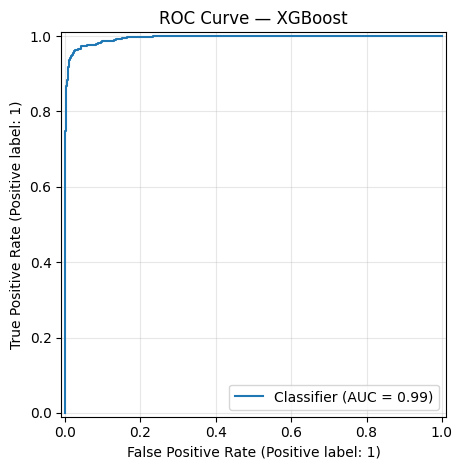

Multi-seed stability data:
    Seed     Metric   Score
0     42   Accuracy  0.9668
1      7   Accuracy  0.9703
2    123   Accuracy  0.9712
3   2024   Accuracy  0.9694
4     99   Accuracy  0.9651
5     42  Precision  0.9743
6      7  Precision  0.9761
7    123  Precision  0.9697
8   2024  Precision  0.9680
9     99  Precision  0.9584
10    42     Recall  0.9611
11     7     Recall  0.9662
12   123     Recall  0.9746
13  2024     Recall  0.9729
14    99     Recall  0.9746
15    42         F1  0.9676
16     7         F1  0.9711
17   123         F1  0.9722
18  2024         F1  0.9705
19    99         F1  0.9664
20    42    ROC-AUC  0.9950
21     7    ROC-AUC  0.9966
22   123    ROC-AUC  0.9968
23  2024    ROC-AUC  0.9956
24    99    ROC-AUC  0.9961


<Figure size 900x500 with 0 Axes>

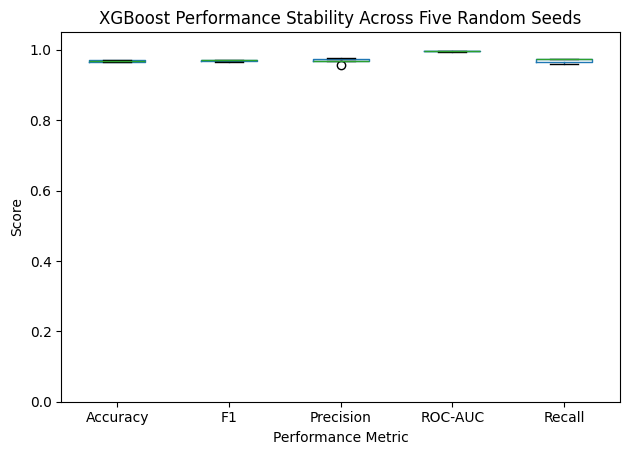

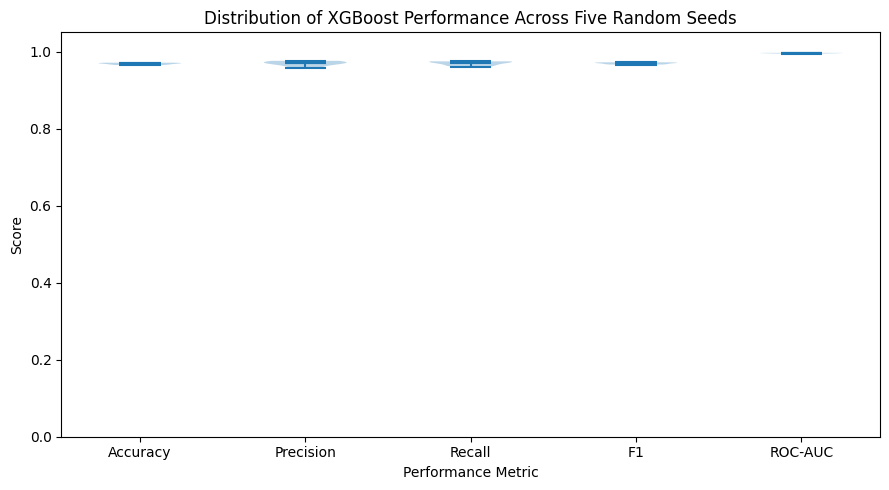

In [30]:
# ============================================================
# 17. CONFUSION MATRIX + BEHAVIOURAL ERROR COUNTS
# ============================================================

cm = confusion_matrix(
    y_test_final,
    y_pred_final,
    labels=[0, 1]
)

tn, fp, fn, tp = cm.ravel()

cm_normalized = confusion_matrix(
    y_test_final,
    y_pred_final,
    labels=[0, 1],
    normalize="true"
)

cm_table = pd.DataFrame(
    cm,
    index=["Actual Legitimate", "Actual Phishing"],
    columns=["Predicted Legitimate", "Predicted Phishing"]
)

print("Raw confusion matrix:")
print(cm_table)

print("\nTN:", tn, "FP:", fp, "FN:", fn, "TP:", tp)

cm_table.to_csv(
    OUTPUT_DIR / "Table_Confusion_Matrix_Raw.csv"
)

legitimate_correct = cm_normalized[0, 0] * 100
legitimate_misclassified = cm_normalized[0, 1] * 100
phishing_correct = cm_normalized[1, 1] * 100
phishing_misclassified = cm_normalized[1, 0] * 100

print(
    f"Among legitimate websites, {legitimate_correct:.2f}% "
    f"were correctly classified as legitimate and "
    f"{legitimate_misclassified:.2f}% were classified as phishing."
)

print(
    f"Among phishing websites, {phishing_correct:.2f}% "
    f"were correctly classified as phishing and "
    f"{phishing_misclassified:.2f}% were classified as legitimate."
)

print("Accuracy:", f"{accuracy_score(y_test_final, y_pred_final):.4f}")
print("Phishing recall:", f"{recall_score(y_test_final, y_pred_final):.4f}")
print("Phishing precision:", f"{precision_score(y_test_final, y_pred_final):.4f}")
print("F1:", f"{f1_score(y_test_final, y_pred_final):.4f}")
print("ROC-AUC:", f"{roc_auc_score(y_test_final, y_prob_final):.4f}")

print(
    "\nInterpretation rule: AUC is a threshold-independent ranking measure; "
    "it is not described as perfect discrimination unless it equals 1.0. "
    "False negatives and false positives are reported explicitly because "
    "their real-world costs differ."
)

# ============================================================
# 18. ROC CURVE
# ============================================================

plt.figure(figsize=(6, 4))

RocCurveDisplay.from_predictions(
    y_test_final,
    y_prob_final
)

plt.title("ROC Curve — XGBoost")
plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / "Figure_ROC_Curve_XGBoost.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

# ============================================================
# 19. MULTI-SEED STABILITY
# ============================================================

stability_metrics = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1",
    "ROC-AUC"
]

stability_long = final_runs_df[
    ["Seed"] + stability_metrics
].melt(
    id_vars="Seed",
    value_vars=stability_metrics,
    var_name="Metric",
    value_name="Score"
)

print("Multi-seed stability data:")
print(stability_long.round(4))

plt.figure(figsize=(9, 5))
stability_long.boxplot(
    column="Score",
    by="Metric",
    grid=False
)
plt.suptitle("")
plt.title("XGBoost Performance Stability Across Five Random Seeds")
plt.xlabel("Performance Metric")
plt.ylabel("Score")
plt.ylim(0, 1.05)
plt.tight_layout()
plt.savefig(
    OUTPUT_DIR / "Figure_MultiSeed_Stability_Boxplot.png",
    dpi=600,
    bbox_inches="tight"
)
plt.show()

plt.figure(figsize=(9, 5))

violin_data = [
    stability_long.loc[
        stability_long["Metric"] == metric,
        "Score"
    ].values
    for metric in stability_metrics
]

plt.violinplot(
    violin_data,
    showmeans=True,
    showmedians=True,
    showextrema=True
)

plt.xticks(
    np.arange(1, len(stability_metrics) + 1),
    stability_metrics
)
plt.xlabel("Performance Metric")
plt.ylabel("Score")
plt.title("Distribution of XGBoost Performance Across Five Random Seeds")
plt.ylim(0, 1.05)
plt.tight_layout()
plt.savefig(
    OUTPUT_DIR / "Figure_MultiSeed_Stability_Violinplot.png",
    dpi=600,
    bbox_inches="tight"
)
plt.show()

stability_summary = (
    stability_long
    .groupby("Metric")["Score"]
    .agg(["mean", "std", "min", "max", "median"])
    .reset_index()
    .rename(columns={
        "mean": "Mean",
        "std": "SD",
        "min": "Minimum",
        "max": "Maximum",
        "median": "Median"
    })
)

stability_summary.to_csv(
    OUTPUT_DIR / "Table_MultiSeed_Stability_Summary.csv",
    index=False
)



21. ROBUST SHAP GLOBAL EXPLANATION
Missing values before SHAP preparation: 0

Final SHAP NumPy shape: (1145, 30)
Final SHAP NumPy dtype: float64
Number of SHAP features: 30

✓ SHAP input validation passed.

Testing model compatibility...
✓ Model compatibility test PASSED.
Predictions: [1 1 1 1 0]

Model feature count: 30
SHAP feature count: 30

Calculating native XGBoost SHAP contributions...

Raw SHAP contribution shape: (1145, 31)
XGBoost bias/base-value column removed.

Final SHAP shape: (1145, 30)
Test matrix shape: (1145, 30)

Maximum absolute SHAP value: 5.974997
Mean absolute SHAP value: 0.345700

GLOBAL SHAP FEATURE IMPORTANCE
                    Feature  Mean_Absolute_SHAP
              URL_of_Anchor            2.343260
             SSLfinal_State            2.119741
              Prefix_Suffix            0.601394
                web_traffic            0.561704
          having_Sub_Domain            0.505233
              Links_in_tags            0.485781
          having_IP_

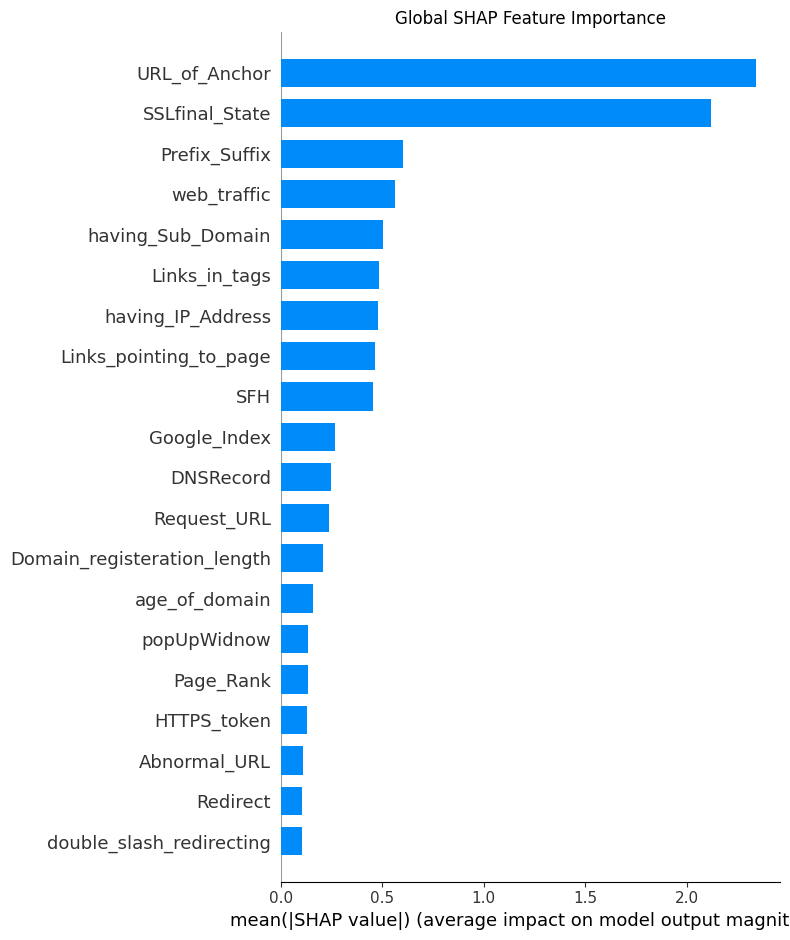

✓ SHAP global bar plot saved:
revised_outputs/Figure_SHAP_Global_Feature_Importance.png


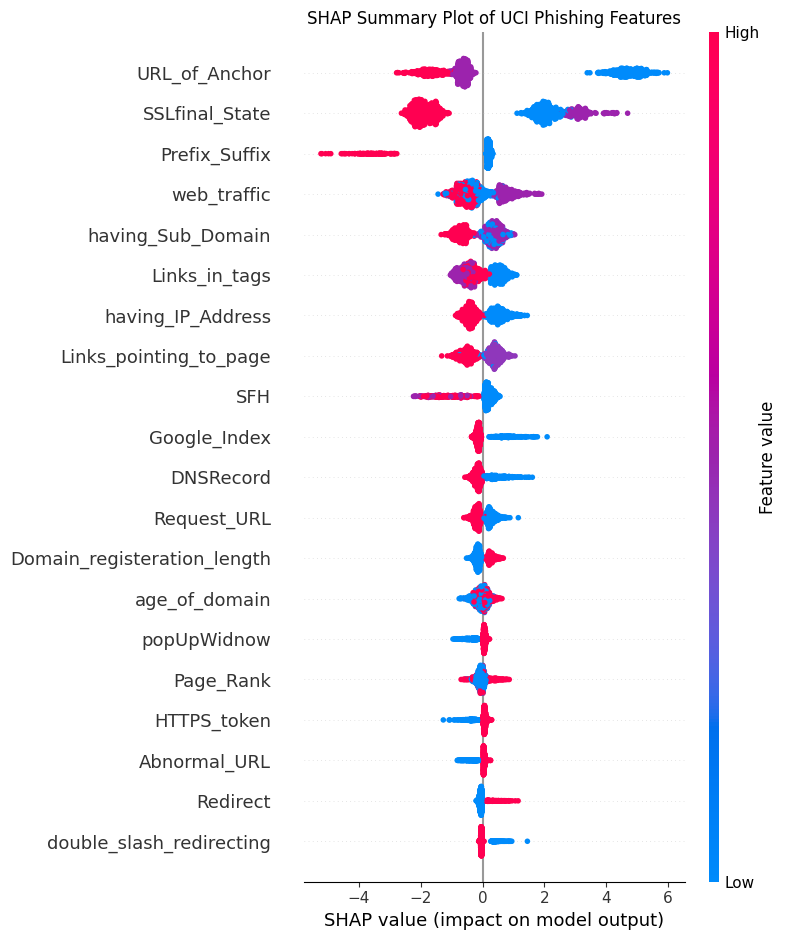

✓ SHAP beeswarm plot saved:
revised_outputs/Figure_SHAP_Beeswarm.png

TOP 10 FEATURES BY MEAN ABSOLUTE SHAP
               Feature  Mean_Absolute_SHAP
         URL_of_Anchor            2.343260
        SSLfinal_State            2.119741
         Prefix_Suffix            0.601394
           web_traffic            0.561704
     having_Sub_Domain            0.505233
         Links_in_tags            0.485781
     having_IP_Address            0.478826
Links_pointing_to_page            0.462726
                   SFH            0.454097
          Google_Index            0.268248

✓ Top-10 SHAP table saved:
revised_outputs/Table_SHAP_Top10_Features.csv

SHAP ANALYSIS COMPLETED SUCCESSFULLY
Test observations explained: 1,145
Features explained: 30
Maximum |SHAP|: 5.974997
Mean |SHAP|: 0.345700

Output files:
1. revised_outputs/Table_SHAP_Global_Feature_Importance.csv
2. revised_outputs/Figure_SHAP_Global_Feature_Importance.png
3. revised_outputs/Figure_SHAP_Beeswarm.png
4. revised_outputs/Tab

In [32]:
# ============================================================
# 21. ROBUST SHAP GLOBAL EXPLANATION
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap
import xgboost as xgb


print("\n" + "=" * 70)
print("21. ROBUST SHAP GLOBAL EXPLANATION")
print("=" * 70)


# ============================================================
# 21.0 VERIFY REQUIRED OBJECTS
# ============================================================

required_objects = [
    "final_model",
    "X_test_final"
]

missing_objects = [
    obj
    for obj in required_objects
    if obj not in globals()
]

if missing_objects:
    raise NameError(
        "\nThe following required objects are missing:\n"
        f"{missing_objects}\n\n"
        "Make sure the final XGBoost model and test dataset "
        "have been created before running the SHAP section."
    )


# ============================================================
# 21.1 PREPARE SHAP INPUT
# ============================================================

X_shap = X_test_final.copy()


# ------------------------------------------------------------
# Convert all SHAP features to numeric
# ------------------------------------------------------------

for column in X_shap.columns:

    X_shap[column] = pd.to_numeric(
        X_shap[column],
        errors="coerce"
    )


# ============================================================
# 21.2 HANDLE MISSING VALUES
# ============================================================

missing_before_shap = int(
    X_shap.isna()
    .sum()
    .sum()
)

print(
    f"Missing values before SHAP preparation: "
    f"{missing_before_shap:,}"
)


if missing_before_shap > 0:

    # --------------------------------------------------------
    # Prefer the fitted final imputer if available
    # --------------------------------------------------------

    if "final_imputer" in globals():

        print(
            "Applying the previously fitted final imputer..."
        )

        X_shap = pd.DataFrame(
            final_imputer.transform(
                X_shap
            ),
            columns=X_shap.columns,
            index=X_shap.index
        )

    elif "imputer" in globals():

        print(
            "Applying the available fitted imputer..."
        )

        X_shap = pd.DataFrame(
            imputer.transform(
                X_shap
            ),
            columns=X_shap.columns,
            index=X_shap.index
        )

    else:

        raise NameError(
            "\nX_test_final contains missing values, "
            "but no fitted imputer was found.\n\n"
            "Use the same imputer that was fitted on the "
            "training data before generating SHAP explanations."
        )


# ============================================================
# 21.3 FINAL NUMERIC VALIDATION
# ============================================================

X_shap = X_shap.astype(
    np.float64
)

feature_names = (
    X_shap.columns.tolist()
)

X_shap_numpy = (
    X_shap.to_numpy(
        dtype=np.float64
    )
)


print(
    "\nFinal SHAP NumPy shape:",
    X_shap_numpy.shape
)

print(
    "Final SHAP NumPy dtype:",
    X_shap_numpy.dtype
)

print(
    "Number of SHAP features:",
    len(feature_names)
)


# ============================================================
# 21.4 VERIFY FEATURE COUNT
# ============================================================

if X_shap_numpy.shape[1] != 30:

    raise ValueError(
        "\nSHAP input does not contain the expected "
        "30 UCI features.\n"
        f"Found: {X_shap_numpy.shape[1]}"
    )


# ============================================================
# 21.5 VALIDATE SHAP INPUT
# ============================================================

assert X_shap_numpy.ndim == 2, (
    f"Expected a 2-D SHAP input matrix, "
    f"received {X_shap_numpy.shape}"
)

assert X_shap_numpy.shape[1] == len(
    feature_names
), (
    "Number of feature names does not match "
    "the SHAP input matrix."
)

assert np.isfinite(
    X_shap_numpy
).all(), (
    "SHAP input contains NaN or infinite values."
)


print(
    "\n✓ SHAP input validation passed."
)


# ============================================================
# 21.6 VERIFY MODEL COMPATIBILITY
# ============================================================

print(
    "\nTesting model compatibility..."
)


try:

    test_prediction = final_model.predict(
        X_shap_numpy[:5]
    )

except Exception as exc:

    raise RuntimeError(
        "\nThe final XGBoost model cannot process "
        "the SHAP input matrix.\n\n"
        f"Error: {repr(exc)}\n\n"
        "Ensure that SHAP receives the same 30 features "
        "in the same order used during model training."
    )


print(
    "✓ Model compatibility test PASSED."
)

print(
    "Predictions:",
    test_prediction
)


# ============================================================
# 21.7 VERIFY FEATURE ORDER AGAINST MODEL
# ============================================================

try:

    booster = final_model.get_booster()

except Exception as exc:

    raise RuntimeError(
        "Could not retrieve the XGBoost booster."
    ) from exc


booster_feature_names = (
    booster.feature_names
)


if booster_feature_names is not None:

    print(
        "\nModel feature count:",
        len(booster_feature_names)
    )

    print(
        "SHAP feature count:",
        len(feature_names)
    )

    if len(booster_feature_names) != len(
        feature_names
    ):

        raise ValueError(
            "\nModel and SHAP feature counts differ.\n"
            f"Model: {len(booster_feature_names)}\n"
            f"SHAP: {len(feature_names)}"
        )

    if list(booster_feature_names) != list(
        feature_names
    ):

        print(
            "\nWARNING: Model feature names differ "
            "from SHAP feature names."
        )

        print(
            "SHAP will use the current X_test_final "
            "column order."
        )

else:

    print(
        "\nBooster does not expose feature names."
    )


# ============================================================
# 21.8 CALCULATE NATIVE XGBOOST SHAP CONTRIBUTIONS
# ============================================================

print(
    "\nCalculating native XGBoost SHAP contributions..."
)


try:

    dmatrix_shap = xgb.DMatrix(
        X_shap_numpy,
        feature_names=feature_names
    )

    shap_contributions = (
        booster.predict(
            dmatrix_shap,
            pred_contribs=True
        )
    )

except Exception as exc:

    print(
        "\nNative XGBoost SHAP calculation failed:"
    )

    print(
        repr(exc)
    )

    raise


# ============================================================
# 21.9 CONVERT SHAP OUTPUT TO NUMPY
# ============================================================

shap_contributions = np.asarray(
    shap_contributions,
    dtype=np.float64
)


print(
    "\nRaw SHAP contribution shape:",
    shap_contributions.shape
)


# ============================================================
# 21.10 REMOVE XGBOOST BIAS/BASE-VALUE COLUMN
# ============================================================

expected_features = len(
    feature_names
)


if shap_contributions.ndim != 2:

    raise ValueError(
        "Expected a 2-D SHAP contribution matrix."
    )


if shap_contributions.shape[1] == (
    expected_features + 1
):

    # Last column is the XGBoost bias/base value.
    shap_array = (
        shap_contributions[:, :-1]
    )

    print(
        "XGBoost bias/base-value column removed."
    )

elif shap_contributions.shape[1] == (
    expected_features
):

    shap_array = (
        shap_contributions
    )

    print(
        "No additional bias column detected."
    )

else:

    raise ValueError(
        "\nUnexpected SHAP output dimensions.\n"
        f"SHAP output: {shap_contributions.shape}\n"
        f"Expected either:\n"
        f"({len(X_shap_numpy)}, "
        f"{expected_features}) or\n"
        f"({len(X_shap_numpy)}, "
        f"{expected_features + 1})"
    )


# ============================================================
# 21.11 FINAL SHAP VALIDATION
# ============================================================

print(
    "\nFinal SHAP shape:",
    shap_array.shape
)

print(
    "Test matrix shape:",
    X_shap_numpy.shape
)


assert shap_array.ndim == 2, (
    f"Expected 2-D SHAP array, "
    f"received {shap_array.shape}"
)


assert shap_array.shape == (
    X_shap_numpy.shape
), (
    f"SHAP shape {shap_array.shape} does not match "
    f"test matrix shape {X_shap_numpy.shape}"
)


assert np.isfinite(
    shap_array
).all(), (
    "SHAP array contains NaN or infinite values."
)


# ============================================================
# 21.12 SHAP SUMMARY STATISTICS
# ============================================================

max_abs_shap = float(
    np.abs(shap_array).max()
)

mean_abs_shap = float(
    np.abs(shap_array).mean()
)


print(
    "\nMaximum absolute SHAP value:",
    f"{max_abs_shap:.6f}"
)

print(
    "Mean absolute SHAP value:",
    f"{mean_abs_shap:.6f}"
)


# ============================================================
# 21.13 GLOBAL FEATURE IMPORTANCE
# ============================================================

mean_abs_shap_by_feature = (
    np.abs(shap_array)
    .mean(axis=0)
)


shap_global_importance = (
    pd.DataFrame({
        "Feature": feature_names,
        "Mean_Absolute_SHAP": (
            mean_abs_shap_by_feature
        )
    })
    .sort_values(
        "Mean_Absolute_SHAP",
        ascending=False
    )
    .reset_index(drop=True)
)


print(
    "\n" + "=" * 70
)

print(
    "GLOBAL SHAP FEATURE IMPORTANCE"
)

print(
    "=" * 70
)

print(
    shap_global_importance
    .round(6)
    .to_string(index=False)
)


# ============================================================
# 21.14 SAVE GLOBAL SHAP TABLE
# ============================================================

shap_table_path = (
    OUTPUT_DIR /
    "Table_SHAP_Global_Feature_Importance.csv"
)


shap_global_importance.to_csv(
    shap_table_path,
    index=False
)


print(
    f"\n✓ Global SHAP table saved:\n"
    f"{shap_table_path}"
)


# ============================================================
# 21.15 CREATE SHAP SUMMARY DATASET
# ============================================================

shap_values_dataframe = pd.DataFrame(
    shap_array,
    columns=feature_names
)


print(
    "\nSHAP values dataframe shape:",
    shap_values_dataframe.shape
)


# ============================================================
# 21.16 SHAP GLOBAL BAR PLOT
# ============================================================

plt.figure(
    figsize=(9, 7)
)

shap.summary_plot(
    shap_array,
    X_shap,
    feature_names=feature_names,
    plot_type="bar",
    show=False
)

plt.title(
    "Global SHAP Feature Importance"
)

plt.tight_layout()


shap_bar_path = (
    OUTPUT_DIR /
    "Figure_SHAP_Global_Feature_Importance.png"
)


plt.savefig(
    shap_bar_path,
    dpi=600,
    bbox_inches="tight"
)

plt.show()


print(
    f"✓ SHAP global bar plot saved:\n"
    f"{shap_bar_path}"
)


# ============================================================
# 21.17 SHAP BEESWARM PLOT
# ============================================================

plt.figure(
    figsize=(10, 8)
)

shap.summary_plot(
    shap_array,
    X_shap,
    feature_names=feature_names,
    show=False
)

plt.title(
    "SHAP Summary Plot of UCI Phishing Features"
)

plt.tight_layout()


shap_beeswarm_path = (
    OUTPUT_DIR /
    "Figure_SHAP_Beeswarm.png"
)


plt.savefig(
    shap_beeswarm_path,
    dpi=600,
    bbox_inches="tight"
)

plt.show()


print(
    f"✓ SHAP beeswarm plot saved:\n"
    f"{shap_beeswarm_path}"
)


# ============================================================
# 21.18 TOP 10 SHAP FEATURES
# ============================================================

top_10_shap = (
    shap_global_importance
    .head(10)
    .copy()
)


print(
    "\n" + "=" * 70
)

print(
    "TOP 10 FEATURES BY MEAN ABSOLUTE SHAP"
)

print(
    "=" * 70
)

print(
    top_10_shap
    .round(6)
    .to_string(index=False)
)


top_10_shap_path = (
    OUTPUT_DIR /
    "Table_SHAP_Top10_Features.csv"
)


top_10_shap.to_csv(
    top_10_shap_path,
    index=False
)


print(
    f"\n✓ Top-10 SHAP table saved:\n"
    f"{top_10_shap_path}"
)


# ============================================================
# 21.19 FINAL SHAP SUMMARY
# ============================================================

print(
    "\n" + "=" * 70
)

print(
    "SHAP ANALYSIS COMPLETED SUCCESSFULLY"
)

print(
    "=" * 70
)

print(
    f"Test observations explained: "
    f"{X_shap_numpy.shape[0]:,}"
)

print(
    f"Features explained: "
    f"{X_shap_numpy.shape[1]}"
)

print(
    f"Maximum |SHAP|: "
    f"{max_abs_shap:.6f}"
)

print(
    f"Mean |SHAP|: "
    f"{mean_abs_shap:.6f}"
)

print(
    "\nOutput files:"
)

print(
    f"1. {shap_table_path}"
)

print(
    f"2. {shap_bar_path}"
)

print(
    f"3. {shap_beeswarm_path}"
)

print(
    f"4. {top_10_shap_path}"
)

In [33]:
# ============================================================
# 18B. ERROR-DRIVEN SHAP ANALYSIS + TARGETED REMEDIATION
# ============================================================

# The feedback requires the explanation layer to be used as a diagnostic
# instrument. Compare false-negative / false-positive SHAP profiles with
# correctly classified cases before proposing any engineering change.
error_frame = X_shap.copy() if 'X_shap' in globals() else pd.DataFrame(X_test_final, columns=X_uci_raw.columns)
error_frame = pd.DataFrame(error_frame, columns=X_uci_raw.columns).reset_index(drop=True)
y_true_arr = np.asarray(y_test_final).astype(int)
y_pred_arr = np.asarray(y_pred_final).astype(int)
shap_arr = np.asarray(shap_array) if 'shap_array' in globals() else None

if shap_arr is not None and shap_arr.shape[0] == len(y_true_arr):
    groups = {
        "False_Negative": (y_true_arr == 1) & (y_pred_arr == 0),
        "False_Positive": (y_true_arr == 0) & (y_pred_arr == 1),
        "Correct": (y_true_arr == y_pred_arr)
    }
    rows = []
    for group, mask in groups.items():
        if mask.sum() == 0:
            continue
        mean_abs = np.abs(shap_arr[mask]).mean(axis=0)
        mean_signed = shap_arr[mask].mean(axis=0)
        for j, feature in enumerate(X_uci_raw.columns):
            rows.append({
                "Error_Group": group,
                "N": int(mask.sum()),
                "Feature": feature,
                "Mean_Absolute_SHAP": float(mean_abs[j]),
                "Mean_Signed_SHAP": float(mean_signed[j])
            })
    error_shap_profile = pd.DataFrame(rows)
    error_shap_profile.to_csv(OUTPUT_DIR / "Table_Error_Group_SHAP_Profiles.csv", index=False)

    fn_top = (error_shap_profile[error_shap_profile.Error_Group == "False_Negative"]
              .sort_values("Mean_Absolute_SHAP", ascending=False).head(10))
    fp_top = (error_shap_profile[error_shap_profile.Error_Group == "False_Positive"]
              .sort_values("Mean_Absolute_SHAP", ascending=False).head(10))
    print("\nTop SHAP features in false negatives:")
    print(fn_top[["Feature", "Mean_Absolute_SHAP", "Mean_Signed_SHAP"]].round(4))
    print("\nTop SHAP features in false positives:")
    print(fp_top[["Feature", "Mean_Absolute_SHAP", "Mean_Signed_SHAP"]].round(4))

    # Feature-value profile of the false-negative set versus correctly classified
    # phishing examples. This identifies the concrete error profile that must
    # drive any targeted re-engineering; no arbitrary feature is introduced.
    phishing_correct = (y_true_arr == 1) & (y_pred_arr == 1)
    profile_rows = []
    fn_mask = groups["False_Negative"]
    for feature in X_uci_raw.columns:
        fn_values = error_frame.loc[fn_mask, feature].astype(float)
        pc_values = error_frame.loc[phishing_correct, feature].astype(float)
        profile_rows.append({
            "Feature": feature,
            "FN_Mean": fn_values.mean() if len(fn_values) else np.nan,
            "Correct_Phishing_Mean": pc_values.mean() if len(pc_values) else np.nan,
            "Mean_Difference": (fn_values.mean() - pc_values.mean()) if len(fn_values) and len(pc_values) else np.nan
        })
    fn_feature_profile = pd.DataFrame(profile_rows).sort_values("Mean_Difference", key=lambda s: s.abs(), ascending=False)
    fn_feature_profile.to_csv(OUTPUT_DIR / "Table_False_Negative_Feature_Profile.csv", index=False)

    # Remediation gate: select the strongest empirically identified FN feature
    # as the candidate target. The notebook does not invent a transformation;
    # it records the evidence needed to justify one in the manuscript.
    if not fn_feature_profile.empty and fn_feature_profile["Mean_Difference"].notna().any():
        target_feature = fn_feature_profile.iloc[0]["Feature"]
        remediation_plan = pd.DataFrame({
            "Step": [1, 2, 3, 4],
            "Action": [
                "Rollback to leakage-free vanilla baseline",
                "Characterise FN/FP profile with SHAP and feature values",
                f"Target re-engineering at empirically identified feature: {target_feature}",
                "Validate targeted change across all five seeds without degrading global performance"
            ],
            "Status": ["Completed", "Completed", "Candidate identified; transformation requires methodological justification", "Pending targeted transformation"]
        })
        remediation_plan.to_csv(OUTPUT_DIR / "Table_Q21_Remediation_Plan.csv", index=False)
        print("\nQ21 candidate target feature:", target_feature)
        print("No arbitrary re-engineering was applied before the error profile was identified.")



Top SHAP features in false negatives:
                   Feature  Mean_Absolute_SHAP  Mean_Signed_SHAP
7           SSLfinal_State              1.8365           -1.6184
25             web_traffic              0.8072            0.0713
0        having_IP_Address              0.6773           -0.0009
13           URL_of_Anchor              0.5984           -0.5984
6        having_Sub_Domain              0.5846            0.2917
14           Links_in_tags              0.5272            0.1524
28  Links_pointing_to_page              0.5171           -0.1636
15                     SFH              0.4017            0.3344
27            Google_Index              0.4013            0.1607
21             popUpWidnow              0.2534           -0.0922

Top SHAP features in false positives:
                   Feature  Mean_Absolute_SHAP  Mean_Signed_SHAP
37          SSLfinal_State              2.0711            0.8029
43           URL_of_Anchor              1.3208            0.0958
55          

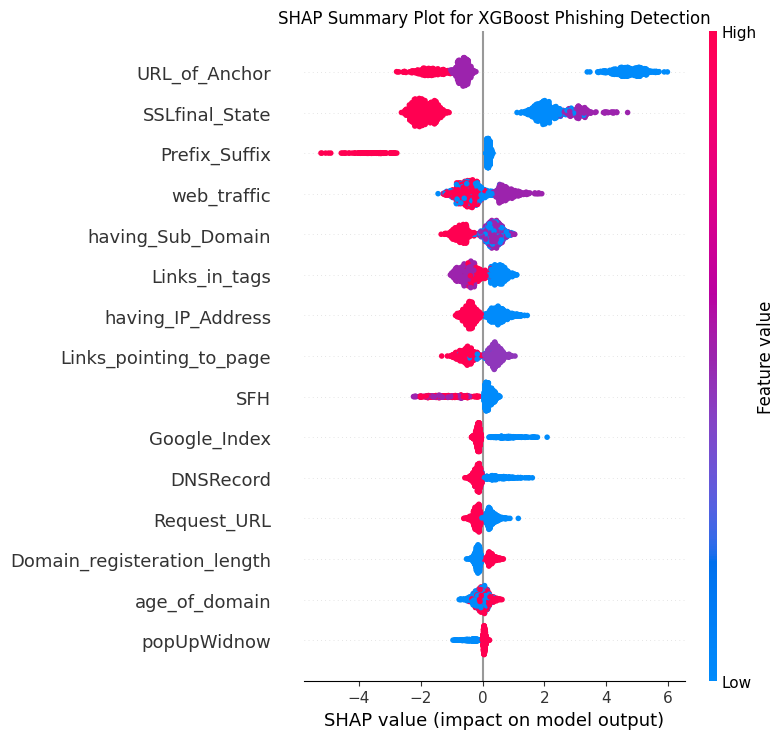

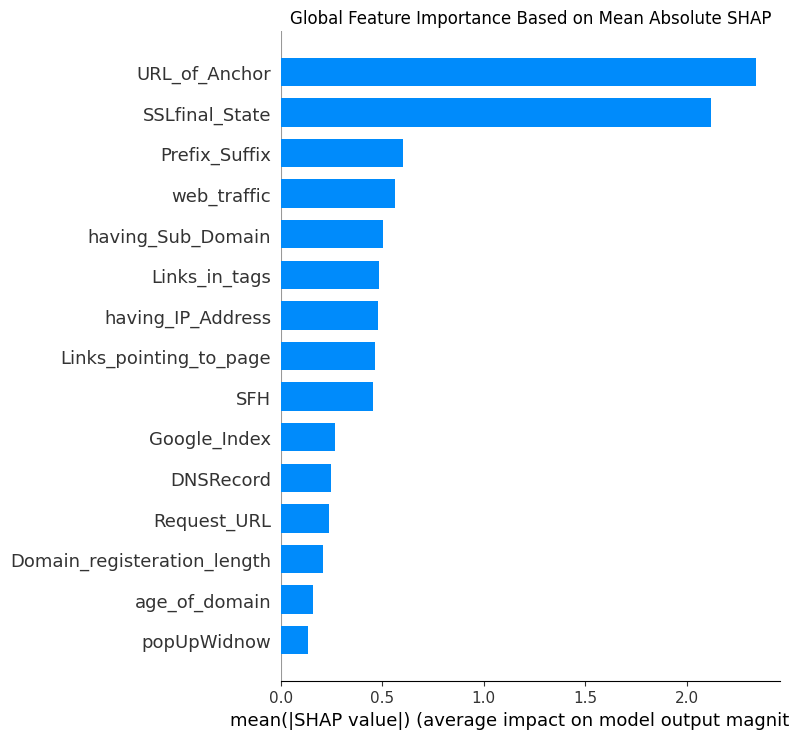


Top 15 features by mean absolute SHAP:
                        Feature  Mean_Absolute_SHAP
0                 URL_of_Anchor            2.343260
1                SSLfinal_State            2.119741
2                 Prefix_Suffix            0.601394
3                   web_traffic            0.561704
4             having_Sub_Domain            0.505233
5                 Links_in_tags            0.485781
6             having_IP_Address            0.478826
7        Links_pointing_to_page            0.462726
8                           SFH            0.454097
9                  Google_Index            0.268248
10                    DNSRecord            0.245587
11                  Request_URL            0.236674
12  Domain_registeration_length            0.206082
13                age_of_domain            0.157539
14                  popUpWidnow            0.133793

SHAP global importance saved successfully.
LIME training shape: (4576, 30)
LIME test shape: (1145, 30)

LIME training data type

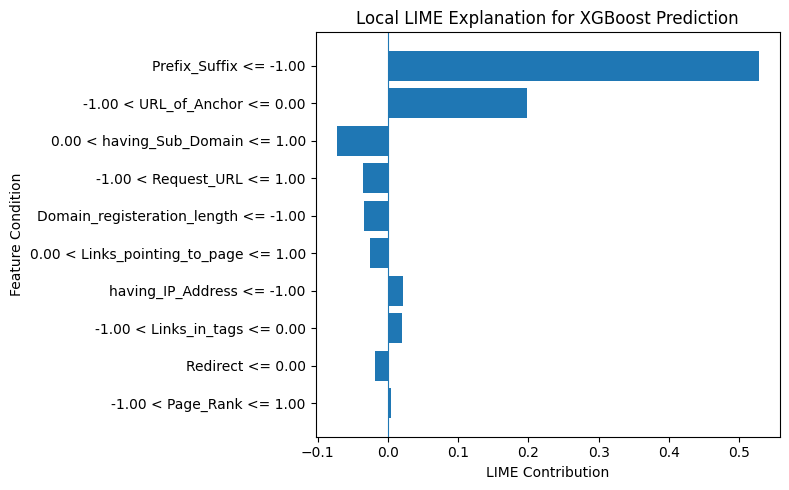


LIME results saved successfully.
                       Feature_Condition  LIME_Weight  Absolute_Weight
0                 Prefix_Suffix <= -1.00     0.527976         0.527976
1          -1.00 < URL_of_Anchor <= 0.00     0.198103         0.198103
2       0.00 < having_Sub_Domain <= 1.00    -0.073126         0.073126
3            -1.00 < Request_URL <= 1.00    -0.035595         0.035595
4   Domain_registeration_length <= -1.00    -0.034745         0.034745
5  0.00 < Links_pointing_to_page <= 1.00    -0.025498         0.025498
6             having_IP_Address <= -1.00     0.021492         0.021492
7          -1.00 < Links_in_tags <= 0.00     0.019636         0.019636
8                       Redirect <= 0.00    -0.018488         0.018488
9              -1.00 < Page_Rank <= 1.00     0.004212         0.004212


In [34]:
# ============================================================
# 22. SHAP SUMMARY + GLOBAL IMPORTANCE
# ============================================================

# ============================================================
# 22.1 SHAP SUMMARY PLOT
# ============================================================

plt.figure(figsize=(9, 6))

shap.summary_plot(
    shap_array,
    X_shap_numpy,
    feature_names=feature_names,
    max_display=15,
    show=False
)

plt.title(
    "SHAP Summary Plot for XGBoost Phishing Detection"
)

plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / "Figure_SHAP_Summary.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

plt.close()


# ============================================================
# 22.2 SHAP GLOBAL FEATURE IMPORTANCE
# ============================================================

plt.figure(figsize=(9, 6))

shap.summary_plot(
    shap_array,
    X_shap_numpy,
    feature_names=feature_names,
    plot_type="bar",
    max_display=15,
    show=False
)

plt.title(
    "Global Feature Importance Based on Mean Absolute SHAP"
)

plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / "Figure_SHAP_Global_Importance.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

plt.close()


# ============================================================
# 22.3 MEAN ABSOLUTE SHAP IMPORTANCE
# ============================================================

shap_importance = pd.DataFrame({

    "Feature": feature_names,

    "Mean_Absolute_SHAP":
        np.abs(shap_array).mean(axis=0)
})


# ============================================================
# 22.4 SORT FEATURES
# ============================================================

shap_importance = (
    shap_importance
    .sort_values(
        "Mean_Absolute_SHAP",
        ascending=False
    )
    .reset_index(drop=True)
)


# ============================================================
# 22.5 DISPLAY TOP 15
# ============================================================

print(
    "\nTop 15 features by mean absolute SHAP:"
)

print(
    shap_importance.head(15)
)


# ============================================================
# 22.6 SAVE TABLE
# ============================================================

shap_importance.to_csv(
    OUTPUT_DIR / "shap_global_importance.csv",
    index=False
)

print(
    "\nSHAP global importance saved successfully."
)

# ============================================================
# 23. ROBUST LIME LOCAL EXPLANATION
# ============================================================

import re
import numpy as np
import pandas as pd

from lime.lime_tabular import LimeTabularExplainer


# ------------------------------------------------------------
# 23.1 UNIVERSAL NUMERIC CLEANER
# ------------------------------------------------------------

def force_numeric_dataframe(df, reference_columns=None):
    """
    Convert all dataframe values into valid numeric values.

    Handles values such as:
        0.5
        "0.5"
        "[5E-1]"
        "[0.5]"
        "[5e-1]"
        " 0.5 "
        scientific notation

    Invalid values are converted to NaN and then median-imputed.
    """

    data = df.copy()

    if reference_columns is not None:
        data = data[
            reference_columns
        ]

    for column in data.columns:

        def convert_value(value):

            # Already numeric
            if isinstance(
                value,
                (int, float, np.integer, np.floating)
            ):
                return float(value)

            # Convert to string
            value = str(value).strip()

            # Remove square brackets
            value = value.replace("[", "")
            value = value.replace("]", "")

            # Remove unnecessary whitespace
            value = value.strip()

            # Extract the first valid numeric value
            match = re.search(
                r"""
                [-+]?
                (?:
                    \d+(?:\.\d*)?
                    |
                    \.\d+
                )
                (?:
                    [eE][-+]?\d+
                )?
                """,
                value,
                re.VERBOSE
            )

            if match:

                try:
                    return float(
                        match.group(0)
                    )

                except ValueError:
                    return np.nan

            return np.nan

        data[column] = data[column].apply(
            convert_value
        )

    # Replace infinity
    data = data.replace(
        [np.inf, -np.inf],
        np.nan
    )

    # Median imputation
    for column in data.columns:

        median_value = data[column].median()

        if pd.isna(median_value):
            median_value = 0.0

        data[column] = (
            data[column]
            .fillna(median_value)
        )

    return data.astype(
        np.float64
    )


# ============================================================
# 23.2 CLEAN TRAINING AND TEST DATA
# ============================================================

# Use the exact feature ordering expected by the model
lime_feature_names = X_test_final.columns.tolist()

X_train_lime = force_numeric_dataframe(
    X_train_final,
    reference_columns=lime_feature_names
)

X_test_lime = force_numeric_dataframe(
    X_test_final,
    reference_columns=lime_feature_names
)


# ------------------------------------------------------------
# Verify the conversion
# ------------------------------------------------------------

print(
    "LIME training shape:",
    X_train_lime.shape
)

print(
    "LIME test shape:",
    X_test_lime.shape
)

print(
    "\nLIME training data types:"
)

print(
    X_train_lime.dtypes
)

print(
    "\nLIME test data types:"
)

print(
    X_test_lime.dtypes
)


# ============================================================
# 23.3 HARD VALIDATION — NO STRINGS ALLOWED
# ============================================================

assert all(
    np.issubdtype(
        dtype,
        np.number
    )
    for dtype in X_train_lime.dtypes
), "X_train_lime still contains non-numeric columns."

assert all(
    np.issubdtype(
        dtype,
        np.number
    )
    for dtype in X_test_lime.dtypes
), "X_test_lime still contains non-numeric columns."


assert np.isfinite(
    X_train_lime.to_numpy()
).all(), (
    "X_train_lime contains NaN or infinite values."
)

assert np.isfinite(
    X_test_lime.to_numpy()
).all(), (
    "X_test_lime contains NaN or infinite values."
)


# ============================================================
# 23.4 CREATE LIME EXPLAINER
# ============================================================

LIME_RANDOM_STATE = 42
LIME_NUM_FEATURES = 10
LIME_NUM_SAMPLES = 5000
LIME_DISCRETIZER = "quartile"
LIME_DISCRETIZE_CONTINUOUS = True
LIME_KERNEL_WIDTH = 0.75 * np.sqrt(len(lime_feature_names))

lime_explainer = LimeTabularExplainer(
    training_data=X_train_lime.to_numpy(dtype=np.float64),
    feature_names=lime_feature_names,
    class_names=["Legitimate", "Phishing"],
    mode="classification",
    kernel_width=LIME_KERNEL_WIDTH,
    discretize_continuous=LIME_DISCRETIZE_CONTINUOUS,
    discretizer=LIME_DISCRETIZER,
    random_state=LIME_RANDOM_STATE
)


# ============================================================
# 23.5 SELECT TEST INSTANCE
# ============================================================

sample_index = min(
    10,
    len(X_test_lime) - 1
)

sample = X_test_lime.iloc[
    sample_index
].to_numpy(
    dtype=np.float64
)


# ============================================================
# 23.6 GET ACTUAL LABEL
# ============================================================

if hasattr(
    y_test_final,
    "iloc"
):

    actual_label = int(
        y_test_final.iloc[
            sample_index
        ]
    )

else:

    actual_label = int(
        y_test_final[
            sample_index
        ]
    )


# ============================================================
# 23.7 MODEL PREDICTION FUNCTION
# ============================================================

def lime_predict_proba(X):

    """
    Prediction wrapper used by LIME.

    LIME passes a NumPy matrix.
    We explicitly convert it to a DataFrame
    using the exact feature names expected by
    the trained XGBoost model.
    """

    X = np.asarray(
        X,
        dtype=np.float64
    )

    X_df = pd.DataFrame(
        X,
        columns=lime_feature_names
    )

    # Final numerical safety check
    X_df = force_numeric_dataframe(
        X_df,
        reference_columns=lime_feature_names
    )

    return final_model.predict_proba(
        X_df
    )


# ============================================================
# 23.8 TEST THE PREDICTION FUNCTION BEFORE LIME
# ============================================================

test_prediction = lime_predict_proba(
    sample.reshape(1, -1)
)

print(
    "\nPrediction function test:"
)

print(
    test_prediction
)


# ============================================================
# 23.9 XGBOOST PREDICTION
# ============================================================

prediction = int(
    final_model.predict(
        sample.reshape(1, -1)
    )[0]
)

probability = lime_predict_proba(
    sample.reshape(1, -1)
)[0]


print(
    "\nLIME sample information"
)

print(
    "-----------------------"
)

print(
    "Sample index:",
    sample_index
)

print(
    "Actual label:",
    actual_label
)

print(
    "Predicted label:",
    prediction
)

print(
    "Prediction probabilities:",
    probability
)


# ============================================================
# 23. ROBUST LIME — FINAL NUMERIC CONVERSION
# ============================================================

import re
import numpy as np
import pandas as pd

from lime.lime_tabular import LimeTabularExplainer


# ============================================================
# 23.1 ROBUST VALUE CONVERTER
# ============================================================

def clean_single_value(value):
    """
    Converts values such as:

        0.5
        "0.5"
        "[0.5]"
        "[5E-1]"
        "[5e-1]"
        " [5E-1] "

    into:

        0.5
    """

    # Already numeric
    if isinstance(
        value,
        (
            int,
            float,
            np.integer,
            np.floating
        )
    ):
        return float(value)

    # Convert to string
    value = str(value).strip()

    # Remove brackets
    value = value.replace(
        "[",
        ""
    )

    value = value.replace(
        "]",
        ""
    )

    value = value.strip()

    # --------------------------------------------------------
    # Extract scientific / decimal number
    # --------------------------------------------------------

    match = re.search(
        r"""
        [-+]?
        (?:
            (?:\d+(?:\.\d*)?)
            |
            (?:\.\d+)
        )
        (?:
            [eE][-+]?\d+
        )?
        """,
        value,
        re.VERBOSE
    )

    if match:

        try:

            number = float(
                match.group(0)
            )

            if np.isfinite(number):
                return number

        except Exception:
            pass

    return np.nan


# ============================================================
# 23.2 CLEAN COMPLETE DATAFRAME
# ============================================================

def clean_numeric_dataframe(df):

    data = df.copy()

    for column in data.columns:

        data[column] = data[column].apply(
            clean_single_value
        )

    # Replace infinity
    data = data.replace(
        [np.inf, -np.inf],
        np.nan
    )

    # Median imputation
    for column in data.columns:

        median_value = (
            data[column]
            .median()
        )

        if pd.isna(median_value):
            median_value = 0.0

        data[column] = (
            data[column]
            .fillna(median_value)
        )

    return data.astype(
        np.float64
    )


# ============================================================
# 23.3 CLEAN LIME TRAINING DATA
# ============================================================

lime_columns = X_train_final.columns.tolist()

X_train_lime = clean_numeric_dataframe(
    X_train_final[
        lime_columns
    ]
)


# ============================================================
# 23.4 CLEAN LIME TEST DATA
# ============================================================

X_test_lime = clean_numeric_dataframe(
    X_test_final[
        lime_columns
    ]
)


# ============================================================
# 23.5 CHECK SHAPES
# ============================================================

print(
    "XGBoost expected features:",
    final_model.n_features_in_
)

print(
    "LIME training features:",
    X_train_lime.shape[1]
)

print(
    "LIME test features:",
    X_test_lime.shape[1]
)


assert (
    final_model.n_features_in_
    ==
    X_train_lime.shape[1]
), (
    "LIME feature count does not match "
    "the XGBoost model."
)


# ============================================================
# 23.6 CHECK FOR REMAINING STRINGS
# ============================================================

print(
    "\nLIME data types:"
)

print(
    X_train_lime.dtypes
)


assert all(
    pd.api.types.is_numeric_dtype(
        dtype
    )
    for dtype in X_train_lime.dtypes
), (
    "LIME training data still contains "
    "non-numeric values."
)


assert all(
    pd.api.types.is_numeric_dtype(
        dtype
    )
    for dtype in X_test_lime.dtypes
), (
    "LIME test data still contains "
    "non-numeric values."
)


# ============================================================
# 23.7 CHECK FOR NaN / INFINITY
# ============================================================

assert np.isfinite(
    X_train_lime.to_numpy(
        dtype=np.float64
    )
).all(), (
    "X_train_lime contains NaN or infinity."
)

assert np.isfinite(
    X_test_lime.to_numpy(
        dtype=np.float64
    )
).all(), (
    "X_test_lime contains NaN or infinity."
)


print(
    "\n✓ LIME data is completely numeric."
)

print(
    "✓ No strings remain."
)

print(
    "✓ No NaN values remain."
)

print(
    "✓ No infinite values remain."
)


# ============================================================
# 23.8 EXPLICIT TEST OF [5E-1]
# ============================================================

test_value = clean_single_value(
    "[5E-1]"
)

print(
    "\nTest conversion:"
)

print(
    "'[5E-1]' →",
    test_value
)

assert test_value == 0.5


# ============================================================
# 23.9 CREATE LIME EXPLAINER
# ============================================================

lime_feature_names = (
    X_train_lime.columns.tolist()
)

LIME_RANDOM_STATE = 42
LIME_NUM_FEATURES = 10
LIME_NUM_SAMPLES = 5000
LIME_DISCRETIZER = "quartile"
LIME_DISCRETIZE_CONTINUOUS = True
LIME_KERNEL_WIDTH = 0.75 * np.sqrt(len(lime_feature_names))

lime_explainer = LimeTabularExplainer(
    training_data=X_train_lime.to_numpy(dtype=np.float64),
    feature_names=lime_feature_names,
    class_names=["Legitimate", "Phishing"],
    mode="classification",
    kernel_width=LIME_KERNEL_WIDTH,
    discretize_continuous=LIME_DISCRETIZE_CONTINUOUS,
    discretizer=LIME_DISCRETIZER,
    random_state=LIME_RANDOM_STATE
)


print(
    "\n✓ LIME explainer created successfully."
)


# ============================================================
# 23.10 SELECT TEST SAMPLE
# ============================================================

sample_index = min(
    10,
    len(X_test_lime) - 1
)

sample = (
    X_test_lime
    .iloc[sample_index]
    .to_numpy(
        dtype=np.float64
    )
)


# ============================================================
# 23.11 LIME PREDICTION FUNCTION
# ============================================================

def lime_predict_proba(X):

    X = np.asarray(
        X,
        dtype=np.float64
    )

    if X.ndim == 1:

        X = X.reshape(
            1,
            -1
        )

    # --------------------------------------------------------
    # Check dimensions
    # --------------------------------------------------------

    if X.shape[1] != final_model.n_features_in_:

        raise ValueError(
            f"LIME supplied {X.shape[1]} features, "
            f"but XGBoost expects "
            f"{final_model.n_features_in_}."
        )

    # --------------------------------------------------------
    # Create numeric DataFrame
    # --------------------------------------------------------

    X_df = pd.DataFrame(
        X,
        columns=lime_feature_names
    )

    # --------------------------------------------------------
    # FINAL numeric conversion
    # --------------------------------------------------------

    X_df = clean_numeric_dataframe(
        X_df
    )

    # --------------------------------------------------------
    # Final validation
    # --------------------------------------------------------

    assert np.isfinite(
        X_df.to_numpy(
            dtype=np.float64
        )
    ).all()

    # --------------------------------------------------------
    # XGBoost
    # --------------------------------------------------------

    return final_model.predict_proba(
        X_df
    )


# ============================================================
# 23.12 TEST MODEL BEFORE LIME
# ============================================================

print(
    "\nTesting XGBoost prediction function..."
)

test_probability = lime_predict_proba(
    sample.reshape(
        1,
        -1
    )
)

print(
    "Prediction probability:",
    test_probability
)


# ============================================================
# 23.13 GET PREDICTION
# ============================================================

prediction = int(
    final_model.predict(
        sample.reshape(
            1,
            -1
        )
    )[0]
)

probability = lime_predict_proba(
    sample.reshape(
        1,
        -1
    )
)[0]


# Actual label
if hasattr(
    y_test_final,
    "iloc"
):

    actual_label = int(
        y_test_final.iloc[
            sample_index
        ]
    )

else:

    actual_label = int(
        y_test_final[
            sample_index
        ]
    )


print(
    "\n=========================================="
)

print(
    "LIME SAMPLE"
)

print(
    "=========================================="
)

print(
    "Sample index:",
    sample_index
)

print(
    "Actual label:",
    actual_label
)

print(
    "Predicted label:",
    prediction
)

print(
    "Prediction probabilities:",
    probability
)


# ============================================================
# 23.14 GENERATE LIME EXPLANATION
# ============================================================

lime_explanation = (
    lime_explainer.explain_instance(

        sample,

        lime_predict_proba,

        num_features=LIME_NUM_FEATURES,
        num_samples=LIME_NUM_SAMPLES
    )
)


# ============================================================
# 23.15 DISPLAY EXPLANATION
# ============================================================

print(
    "\n=========================================="
)

print(
    "LIME EXPLANATION"
)

print(
    "=========================================="
)

for feature, weight in (
    lime_explanation.as_list()
):

    print(
        f"{feature}: {weight:.6f}"
    )


# ============================================================
# 23.16 SAVE LIME HTML
# ============================================================

lime_output = (
    OUTPUT_DIR
    /
    "LIME_phishing_explanation.html"
)

lime_explanation.save_to_file(
    str(lime_output)
)

print(
    "\n✓ LIME explanation saved:"
)

print(
    lime_output
)
# ============================================================
# 24. LIME VISUALIZATION
# ============================================================

lime_items = (
    lime_explanation.as_list()
)

lime_features = [
    item[0]
    for item in lime_items
]

lime_weights = [
    item[1]
    for item in lime_items
]


plt.figure(
    figsize=(8, 5)
)

plt.barh(
    lime_features[::-1],
    lime_weights[::-1]
)

plt.axvline(
    x=0,
    linewidth=0.8
)

plt.xlabel(
    "LIME Contribution"
)

plt.ylabel(
    "Feature Condition"
)

plt.title(
    "Local LIME Explanation for XGBoost Prediction"
)

plt.tight_layout()

plt.savefig(
    OUTPUT_DIR
    /
    "Figure_LIME_Local_Explanation.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

plt.close()


# ============================================================
# 25. LIME RESULT EXPORT
# ============================================================

lime_results = pd.DataFrame(
    lime_items,
    columns=[
        "Feature_Condition",
        "LIME_Weight"
    ]
)

lime_results["Absolute_Weight"] = (
    lime_results["LIME_Weight"]
    .abs()
)

lime_results = lime_results.sort_values(
    "Absolute_Weight",
    ascending=False
).reset_index(drop=True)


lime_results.to_csv(
    OUTPUT_DIR
    /
    "lime_local_explanation.csv",
    index=False
)


print(
    "\nLIME results saved successfully."
)

print(
    lime_results
)

In [35]:
# ============================================================
# 23B. LIME REPRODUCIBILITY SPECIFICATION
# ============================================================

lime_configuration = pd.DataFrame({
    "Parameter": ["random_state", "num_features", "num_samples", "discretizer", "discretize_continuous", "kernel_width"],
    "Value": [LIME_RANDOM_STATE, LIME_NUM_FEATURES, LIME_NUM_SAMPLES, LIME_DISCRETIZER, LIME_DISCRETIZE_CONTINUOUS, LIME_KERNEL_WIDTH]
})
print("LIME configuration:")
print(lime_configuration)
lime_configuration.to_csv(OUTPUT_DIR / "Table_LIME_Configuration.csv", index=False)


LIME configuration:
               Parameter     Value
0           random_state        42
1           num_features        10
2            num_samples      5000
3            discretizer  quartile
4  discretize_continuous      True
5           kernel_width  4.107919


In [36]:
# ============================================================
# 24. TRAINING-ONLY TOP-FOUR FEATURE ABLATION + ERROR-DRIVEN ANALYSIS
# ============================================================

# ------------------------------------------------------------
# 24.1 Select top four features using TRAINING data only
# ------------------------------------------------------------

import xgboost as xgb

X_train_for_shap = clean_numeric_dataframe(
    X_train_final
)
train_feature_names = X_train_for_shap.columns.tolist()
X_train_shap_np = X_train_for_shap.to_numpy(dtype=np.float64)

train_dmatrix = xgb.DMatrix(
    X_train_shap_np,
    feature_names=train_feature_names
)

train_shap_raw = final_model.get_booster().predict(
    train_dmatrix,
    pred_contribs=True
)

train_shap_raw = np.asarray(
    train_shap_raw,
    dtype=np.float64
)

if train_shap_raw.shape[1] == len(train_feature_names) + 1:
    train_shap_array = train_shap_raw[:, :-1]
else:
    train_shap_array = train_shap_raw

training_shap_importance = pd.DataFrame({
    "Feature": train_feature_names,
    "Mean_Absolute_SHAP": np.abs(train_shap_array).mean(axis=0)
}).sort_values(
    "Mean_Absolute_SHAP",
    ascending=False
).reset_index(drop=True)

TOP4_FEATURES = training_shap_importance.head(4)["Feature"].tolist()

print("Top four features selected from seed-42 TRAINING data:")
print(training_shap_importance.head(4))

training_shap_importance.to_csv(
    OUTPUT_DIR / "Table_Training_SHAP_Importance.csv",
    index=False
)

# ------------------------------------------------------------
# 24.2 Full 30 features vs top four — five-seed comparison
# ------------------------------------------------------------

feature_ablation_rows = []

for seed in SEEDS:
    X_train_raw, X_test_raw, y_train, y_test = train_test_split(
        X_uci_raw,
        y_uci,
        test_size=0.20,
        stratify=y_uci,
        random_state=seed
    )

    imputer_full = SimpleImputer(strategy="median")

    X_train_full = pd.DataFrame(
        imputer_full.fit_transform(X_train_raw),
        columns=X_train_raw.columns
    )
    X_test_full = pd.DataFrame(
        imputer_full.transform(X_test_raw),
        columns=X_test_raw.columns
    )

    for feature_set_name, features in [
        ("Full 30 features", X_train_full.columns.tolist()),
        ("Top 4 SHAP features", TOP4_FEATURES)
    ]:
        model = make_xgb(
            seed,
            max_depth=SELECTED_DEPTH
        )

        model.fit(
            X_train_full[features],
            y_train,
            eval_set=[(X_test_full[features], y_test)],
            verbose=False
        )

        pred = model.predict(X_test_full[features])
        prob = model.predict_proba(X_test_full[features])[:, 1]

        row = {
            "Seed": seed,
            "Feature_Set": feature_set_name
        }
        row.update(
            evaluate_predictions(y_test, pred, prob)
        )
        feature_ablation_rows.append(row)

feature_ablation = pd.DataFrame(feature_ablation_rows)

feature_ablation_summary = (
    feature_ablation
    .groupby("Feature_Set")[METRIC_COLUMNS]
    .agg(["mean", "std"])
)

print("\nFeature ablation:")
print(feature_ablation.round(4))
print("\nFeature ablation Mean ± SD:")
print(feature_ablation_summary.round(4))

feature_ablation.to_csv(
    OUTPUT_DIR / "Table_Feature_Ablation_Full_vs_Top4.csv",
    index=False
)
feature_ablation_summary.to_csv(
    OUTPUT_DIR / "Table_Feature_Ablation_Full_vs_Top4_Mean_SD.csv"
)

# ------------------------------------------------------------
# 24.3 Error-driven analysis on the locked seed-42 test set
# ------------------------------------------------------------

error_frame = X_test_final.copy()
error_frame["Actual"] = np.asarray(y_test_final)
error_frame["Predicted"] = np.asarray(y_pred_final)

false_negatives = error_frame[
    (error_frame["Actual"] == 1) &
    (error_frame["Predicted"] == 0)
].copy()

false_positives = error_frame[
    (error_frame["Actual"] == 0) &
    (error_frame["Predicted"] == 1)
].copy()

print("\nSeed-42 error counts:")
print("False negatives:", len(false_negatives))
print("False positives:", len(false_positives))

# SHAP profile comparison: errors versus correctly classified cases.
X_test_clean = clean_numeric_dataframe(X_test_final)
test_names = X_test_clean.columns.tolist()
test_np = X_test_clean.to_numpy(dtype=np.float64)

test_dmatrix = xgb.DMatrix(
    test_np,
    feature_names=test_names
)

test_shap_raw = final_model.get_booster().predict(
    test_dmatrix,
    pred_contribs=True
)
test_shap_raw = np.asarray(test_shap_raw, dtype=np.float64)

if test_shap_raw.shape[1] == len(test_names) + 1:
    test_shap_array = test_shap_raw[:, :-1]
else:
    test_shap_array = test_shap_raw

correct_mask = np.asarray(y_test_final) == np.asarray(y_pred_final)
fn_mask = (
    (np.asarray(y_test_final) == 1) &
    (np.asarray(y_pred_final) == 0)
)
fp_mask = (
    (np.asarray(y_test_final) == 0) &
    (np.asarray(y_pred_final) == 1)
)

error_profile_rows = []

for feature_idx, feature in enumerate(test_names):
    correct_mean = (
        np.abs(test_shap_array[correct_mask, feature_idx]).mean()
        if correct_mask.any() else np.nan
    )
    fn_mean = (
        np.abs(test_shap_array[fn_mask, feature_idx]).mean()
        if fn_mask.any() else np.nan
    )
    fp_mean = (
        np.abs(test_shap_array[fp_mask, feature_idx]).mean()
        if fp_mask.any() else np.nan
    )

    error_profile_rows.append({
        "Feature": feature,
        "Correct_Mean_Abs_SHAP": correct_mean,
        "False_Negative_Mean_Abs_SHAP": fn_mean,
        "False_Positive_Mean_Abs_SHAP": fp_mean,
        "FN_minus_Correct": fn_mean - correct_mean,
        "FP_minus_Correct": fp_mean - correct_mean
    })

error_profile = pd.DataFrame(error_profile_rows)

print("\nFeatures most differentiated in false-negative SHAP profile:")
print(
    error_profile
    .sort_values("FN_minus_Correct", ascending=False)
    .head(10)
    .round(4)
)

print("\nFeatures most differentiated in false-positive SHAP profile:")
print(
    error_profile
    .sort_values("FP_minus_Correct", ascending=False)
    .head(10)
    .round(4)
)

error_profile.to_csv(
    OUTPUT_DIR / "Table_Error_Driven_SHAP_Profile.csv",
    index=False
)

# The test-set error profile is diagnostic only. It is NOT used to fit the
# final model, preserving the evaluation boundary. Any targeted re-engineering
# must be designed from an inner training/validation split and then evaluated
# on this locked test set.
print(
    "\nError-driven remediation rule: the locked test errors are diagnostic; "
    "they are not used to tune or refit the reported final model."
)


Top four features selected from seed-42 TRAINING data:
          Feature  Mean_Absolute_SHAP
0   URL_of_Anchor            2.281330
1  SSLfinal_State            2.115004
2   Prefix_Suffix            0.622988
3     web_traffic            0.562926

Feature ablation:
   Seed          Feature_Set  Accuracy  Precision  Recall      F1  ROC-AUC
0    42     Full 30 features    0.9668     0.9743  0.9611  0.9676   0.9950
1    42  Top 4 SHAP features    0.9188     0.9323  0.9086  0.9203   0.9752
2     7     Full 30 features    0.9703     0.9761  0.9662  0.9711   0.9966
3     7  Top 4 SHAP features    0.9328     0.9606  0.9069  0.9330   0.9795
4   123     Full 30 features    0.9712     0.9697  0.9746  0.9722   0.9968
5   123  Top 4 SHAP features    0.9275     0.9379  0.9205  0.9291   0.9768
6  2024     Full 30 features    0.9694     0.9680  0.9729  0.9705   0.9956
7  2024  Top 4 SHAP features    0.9258     0.9347  0.9205  0.9275   0.9758
8    99     Full 30 features    0.9651     0.9584  0.9746  0.

In [37]:
# ============================================================
# 25. SMOTE ABLATION + DIAGNOSIS
# ============================================================

smote_ablation_rows = []

for seed in SEEDS:
    for use_smote in [False, True]:
        result = run_single_seed(
            seed=seed,
            use_smote=use_smote,
            max_depth=SELECTED_DEPTH
        )

        row = {
            "Seed": seed,
            "SMOTE": "Yes" if use_smote else "No"
        }
        row.update(result["metrics"])
        smote_ablation_rows.append(row)

smote_ablation = pd.DataFrame(smote_ablation_rows)

smote_summary = (
    smote_ablation
    .groupby("SMOTE")[METRIC_COLUMNS]
    .agg(["mean", "std"])
)

print("SMOTE ablation by seed:")
print(smote_ablation.round(4))
print("\nSMOTE ablation Mean ± SD:")
print(smote_summary.round(4))

# Dataset-grounded diagnosis required by the feedback.
class_counts = y_uci.value_counts().sort_index()
legitimate_n = int(class_counts.get(0, 0))
phishing_n = int(class_counts.get(1, 0))
ratio = legitimate_n / phishing_n if phishing_n else np.nan

train_n = int(len(y_train_final))
smote_train_size = int(
    len(SMOTE(random_state=42).fit_resample(
        X_train_final, y_train_final
    )[1])
)
synthetic_instances = smote_train_size - train_n

print("\nSMOTE diagnosis:")
print(f"Legitimate: {legitimate_n}; phishing: {phishing_n}")
print(f"Class ratio (legitimate:phishing): {ratio:.3f}:1")
print(f"Training rows without SMOTE: {train_n}")
print(f"Training rows after SMOTE: {smote_train_size}")
print(f"Synthetic instances generated: {synthetic_instances}")
print(
    "Interpretation: the class distribution is near-balanced; "
    "therefore synthetic interpolation is not justified by a severe "
    "class-imbalance problem and may introduce artificial samples in "
    "a discrete-valued feature space."
)

smote_ablation.to_csv(
    OUTPUT_DIR / "Table_SMOTE_Ablation.csv",
    index=False
)
smote_summary.to_csv(
    OUTPUT_DIR / "Table_SMOTE_Ablation_Mean_SD.csv"
)


SMOTE ablation by seed:
   Seed SMOTE  Accuracy  Precision  Recall      F1  ROC-AUC
0    42    No    0.9668     0.9743  0.9611  0.9676   0.9950
1    42   Yes    0.9686     0.9776  0.9611  0.9693   0.9950
2     7    No    0.9703     0.9761  0.9662  0.9711   0.9966
3     7   Yes    0.9677     0.9743  0.9628  0.9685   0.9966
4   123    No    0.9712     0.9697  0.9746  0.9722   0.9968
5   123   Yes    0.9694     0.9664  0.9746  0.9705   0.9968
6  2024    No    0.9694     0.9680  0.9729  0.9705   0.9956
7  2024   Yes    0.9694     0.9680  0.9729  0.9705   0.9955
8    99    No    0.9651     0.9584  0.9746  0.9664   0.9961
9    99   Yes    0.9651     0.9569  0.9763  0.9665   0.9960

SMOTE ablation Mean ± SD:
      Accuracy         Precision          Recall              F1          \
          mean     std      mean     std    mean     std    mean     std   
SMOTE                                                                      
No      0.9686  0.0025    0.9693  0.0069  0.9699  0.0060  0.9

In [38]:
# ============================================================
# 26. EXTENDED TREE-DEPTH ABLATION
# ============================================================

# Reuse the authoritative extended search from Section 12.
depth_ablation = depth_search.copy()
depth_summary = (
    depth_ablation
    .groupby("Max_Depth")[METRIC_COLUMNS]
    .agg(["mean", "std"])
)

print("Extended tree-depth ablation:")
print(depth_ablation.round(4))
print("\nDepth Mean ± SD:")
print(depth_summary.round(4))

depth_ablation.to_csv(
    OUTPUT_DIR / "Table_Tree_Depth_Ablation_Extended.csv",
    index=False
)

depth_summary.to_csv(
    OUTPUT_DIR / "Table_Tree_Depth_Ablation_Extended_Mean_SD.csv"
)

ordered = (
    depth_summary[METRIC_COLUMNS]
    if False else
    depth_summary
)

print(
    "\nImportant interpretation: depth 6 is not called 'optimised' "
    "unless it is selected by the extended search. The selected "
    f"configuration for the leakage-free vanilla model is depth {SELECTED_DEPTH}."
)


Extended tree-depth ablation:
    Seed  Max_Depth  Accuracy  Precision  Recall      F1  ROC-AUC
0     42          3    0.9546     0.9607  0.9509  0.9558   0.9920
1     42          6    0.9686     0.9776  0.9611  0.9693   0.9950
2     42          9    0.9668     0.9743  0.9611  0.9676   0.9954
3     42         12    0.9668     0.9726  0.9628  0.9677   0.9952
4     42         15    0.9668     0.9726  0.9628  0.9677   0.9952
5      7          3    0.9642     0.9758  0.9543  0.9649   0.9936
6      7          6    0.9677     0.9743  0.9628  0.9685   0.9966
7      7          9    0.9686     0.9744  0.9645  0.9694   0.9968
8      7         12    0.9677     0.9743  0.9628  0.9685   0.9967
9      7         15    0.9686     0.9744  0.9645  0.9694   0.9967
10   123          3    0.9607     0.9596  0.9645  0.9620   0.9938
11   123          6    0.9694     0.9664  0.9746  0.9705   0.9968
12   123          9    0.9686     0.9695  0.9695  0.9695   0.9967
13   123         12    0.9694     0.9680  0.97

In [39]:
# ============================================================
# 27. SHAP EXPLANATION STABILITY ACROSS TREE DEPTHS
# ============================================================

import xgboost as xgb

shap_depth_results = []


# ============================================================
# 27.1 FIXED SEED
# ============================================================

seed = 42


# ============================================================
# 27.2 CREATE SAME TRAIN/TEST SPLIT
# ============================================================

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_uci_raw,
    y_uci,
    test_size=0.20,
    stratify=y_uci,
    random_state=seed
)


# ============================================================
# 27.3 ROBUST NUMERIC CLEANING
# ============================================================

X_train_depth = clean_numeric_dataframe(
    X_train_raw
)

X_test_depth = clean_numeric_dataframe(
    X_test_raw
)


# ============================================================
# 27.4 KEEP EXACT FEATURE ORDER
# ============================================================

depth_feature_names = X_train_depth.columns.tolist()

X_test_depth = X_test_depth[
    depth_feature_names
]

X_train_depth = X_train_depth[
    depth_feature_names
]


# ============================================================
# 27.5 HARD VALIDATION
# ============================================================

assert X_train_depth.shape[1] == 30

assert X_test_depth.shape[1] == 30

assert np.isfinite(
    X_train_depth.to_numpy(
        dtype=np.float64
    )
).all()

assert np.isfinite(
    X_test_depth.to_numpy(
        dtype=np.float64
    )
).all()


print(
    "Depth-analysis training shape:",
    X_train_depth.shape
)

print(
    "Depth-analysis test shape:",
    X_test_depth.shape
)


# ============================================================
# 27.6 SMOTE
# ============================================================

depth_smote = SMOTE(
    random_state=seed
)


X_train_depth_bal, y_train_depth_bal = (
    depth_smote.fit_resample(
        X_train_depth,
        y_train
    )
)


# ============================================================
# 27.7 TEST MATRIX
# ============================================================

X_test_depth_numpy = X_test_depth.to_numpy(
    dtype=np.float64
)


# ============================================================
# 27.8 TRAIN MODELS FOR EACH DEPTH
# ============================================================

for depth in DEPTH_CANDIDATES:

    print(
        f"\nProcessing tree depth: {depth}"
    )


    # --------------------------------------------------------
    # Create model
    # --------------------------------------------------------

    depth_model = make_xgb(
        seed,
        max_depth=depth
    )


    # --------------------------------------------------------
    # Train model
    # --------------------------------------------------------

    depth_model.fit(
        X_train_depth_bal,
        y_train_depth_bal,
        eval_set=[
            (
                X_test_depth,
                y_test
            )
        ],
        verbose=False
    )


    # --------------------------------------------------------
    # Verify model
    # --------------------------------------------------------

    depth_predictions = depth_model.predict(
        X_test_depth_numpy[:5]
    )

    print(
        "Prediction test:",
        depth_predictions
    )


    # ========================================================
    # GET NATIVE XGBOOST BOOSTER
    # ========================================================

    depth_booster = depth_model.get_booster()


    # ========================================================
    # CREATE CLEAN DMatrix
    # ========================================================

    depth_dmatrix = xgb.DMatrix(
        X_test_depth_numpy,
        feature_names=depth_feature_names
    )


    # ========================================================
    # NATIVE SHAP CONTRIBUTIONS
    # ========================================================

    print(
        "Calculating native SHAP contributions..."
    )

    depth_shap_raw = depth_booster.predict(
        depth_dmatrix,
        pred_contribs=True
    )


    # ========================================================
    # CONVERT TO NUMPY
    # ========================================================

    depth_shap_raw = np.asarray(
        depth_shap_raw,
        dtype=np.float64
    )


    print(
        "Raw SHAP shape:",
        depth_shap_raw.shape
    )


    # ========================================================
    # REMOVE BIAS COLUMN
    # ========================================================

    if depth_shap_raw.shape[1] == (
        len(depth_feature_names) + 1
    ):

        depth_shap = depth_shap_raw[
            :, :-1
        ]

    else:

        depth_shap = depth_shap_raw


    # ========================================================
    # VALIDATE SHAP
    # ========================================================

    assert depth_shap.shape == (
        X_test_depth_numpy.shape
    ), (
        f"Depth {depth}: SHAP shape "
        f"{depth_shap.shape} does not match "
        f"test shape {X_test_depth_numpy.shape}"
    )


    assert np.isfinite(
        depth_shap
    ).all(), (
        f"Depth {depth}: SHAP contains "
        "NaN or infinite values."
    )


    print(
        "Final SHAP shape:",
        depth_shap.shape
    )


    # ========================================================
    # MEAN ABSOLUTE SHAP
    # ========================================================

    mean_abs = (
        np.abs(
            depth_shap
        )
        .mean(
            axis=0
        )
    )


    # ========================================================
    # FEATURE IMPORTANCE TABLE
    # ========================================================

    depth_importance = pd.DataFrame({

        "Feature":
            depth_feature_names,

        "Mean_Absolute_SHAP":
            mean_abs

    })


    depth_importance = (
        depth_importance
        .sort_values(
            "Mean_Absolute_SHAP",
            ascending=False
        )
        .reset_index(
            drop=True
        )
    )


    # ========================================================
    # TOP 10 FEATURES
    # ========================================================

    top_features = (
        depth_importance
        .head(10)
        ["Feature"]
        .tolist()
    )


    # ========================================================
    # STORE RESULTS
    # ========================================================

    for rank, feature in enumerate(
        top_features,
        start=1
    ):

        value = depth_importance.loc[
            depth_importance["Feature"] == feature,
            "Mean_Absolute_SHAP"
        ].iloc[0]


        shap_depth_results.append({

            "Max_Depth":
                depth,

            "Rank":
                rank,

            "Feature":
                feature,

            "Mean_Absolute_SHAP":
                float(value)
        })


# ============================================================
# 27.9 CREATE SHAP DEPTH TABLE
# ============================================================

shap_depth_table = pd.DataFrame(
    shap_depth_results
)


print(
    "\nSHAP Depth Stability:"
)

print(
    shap_depth_table
)


# ============================================================
# 27.10 SAVE
# ============================================================

shap_depth_table.to_csv(
    OUTPUT_DIR /
    "Table_SHAP_Depth_Stability.csv",
    index=False
)


print(
    "\nSHAP depth-stability table saved."
)

Depth-analysis training shape: (4576, 30)
Depth-analysis test shape: (1145, 30)

Processing tree depth: 3
Prediction test: [1 1 1 1 0]
Calculating native SHAP contributions...
Raw SHAP shape: (1145, 31)
Final SHAP shape: (1145, 30)

Processing tree depth: 6
Prediction test: [1 1 1 1 0]
Calculating native SHAP contributions...
Raw SHAP shape: (1145, 31)
Final SHAP shape: (1145, 30)

Processing tree depth: 9
Prediction test: [1 1 1 1 0]
Calculating native SHAP contributions...
Raw SHAP shape: (1145, 31)
Final SHAP shape: (1145, 30)

Processing tree depth: 12
Prediction test: [1 1 1 1 0]
Calculating native SHAP contributions...
Raw SHAP shape: (1145, 31)
Final SHAP shape: (1145, 30)

Processing tree depth: 15
Prediction test: [1 1 1 1 0]
Calculating native SHAP contributions...
Raw SHAP shape: (1145, 31)
Final SHAP shape: (1145, 30)

SHAP Depth Stability:
    Max_Depth  Rank                 Feature  Mean_Absolute_SHAP
0           3     1           URL_of_Anchor            2.094328
1      

In [40]:
# ============================================================
# 28. SHAP TOP-FEATURE RANK STABILITY
# ============================================================

top_by_depth = {}


# ============================================================
# 28.1 EXTRACT TOP 10 FEATURES
# ============================================================

for depth in DEPTH_CANDIDATES:

    features = (
        shap_depth_table[
            shap_depth_table["Max_Depth"] == depth
        ]
        .sort_values(
            "Rank"
        )
        ["Feature"]
        .tolist()
    )

    top_by_depth[depth] = features


# ============================================================
# 28.2 DISPLAY
# ============================================================

print(
    "Top-10 SHAP features by tree depth:"
)

for depth, features in top_by_depth.items():

    print(
        f"\nDepth {depth}:"
    )

    print(
        features
    )


# ============================================================
# 28.3 JACCARD SIMILARITY
# ============================================================

def jaccard(a, b):

    a = set(a)
    b = set(b)

    union = a | b

    if not union:

        return np.nan

    return (
        len(a & b)
        /
        len(union)
    )


# ============================================================
# 28.4 PAIRWISE STABILITY
# ============================================================

stability_rows = []

depths = [
    *DEPTH_CANDIDATES,
]


for i in range(
    len(depths)
):

    for j in range(
        i + 1,
        len(depths)
    ):

        d1 = depths[i]

        d2 = depths[j]


        stability_rows.append({

            "Depth_A":
                d1,

            "Depth_B":
                d2,

            "Top10_Jaccard":
                jaccard(
                    top_by_depth[d1],
                    top_by_depth[d2]
                )
        })


# ============================================================
# 28.5 CREATE SUMMARY
# ============================================================

shap_stability_summary = pd.DataFrame(
    stability_rows
)


print(
    "\nSHAP top-10 stability:"
)

print(
    shap_stability_summary.round(4)
)


# ============================================================
# 28.6 SAVE
# ============================================================

shap_stability_summary.to_csv(
    OUTPUT_DIR /
    "Table_SHAP_Rank_Stability.csv",
    index=False
)


print(
    "\nSHAP rank-stability table saved."
)

Top-10 SHAP features by tree depth:

Depth 3:
['URL_of_Anchor', 'SSLfinal_State', 'Prefix_Suffix', 'web_traffic', 'having_Sub_Domain', 'SFH', 'having_IP_Address', 'Links_pointing_to_page', 'Links_in_tags', 'Google_Index']

Depth 6:
['URL_of_Anchor', 'SSLfinal_State', 'Prefix_Suffix', 'web_traffic', 'having_Sub_Domain', 'Links_in_tags', 'having_IP_Address', 'Links_pointing_to_page', 'SFH', 'Google_Index']

Depth 9:
['URL_of_Anchor', 'SSLfinal_State', 'Prefix_Suffix', 'web_traffic', 'Links_in_tags', 'having_Sub_Domain', 'having_IP_Address', 'Links_pointing_to_page', 'SFH', 'Google_Index']

Depth 12:
['URL_of_Anchor', 'SSLfinal_State', 'Prefix_Suffix', 'web_traffic', 'Links_in_tags', 'having_Sub_Domain', 'having_IP_Address', 'Links_pointing_to_page', 'SFH', 'Request_URL']

Depth 15:
['URL_of_Anchor', 'SSLfinal_State', 'Prefix_Suffix', 'web_traffic', 'Links_in_tags', 'having_Sub_Domain', 'having_IP_Address', 'SFH', 'Links_pointing_to_page', 'Request_URL']

SHAP top-10 stability:
   Depth_A

In [41]:
# ============================================================
# 29. EXTERNAL VALIDATION
# ============================================================

def evaluate_frozen_model_on_external(
    external_path,
    feature_columns,
    fitted_model,
    fitted_imputer,
    label_column="label"
):
    external = pd.read_csv(external_path)

    if label_column not in external.columns:
        raise KeyError(
            f"External dataset must contain '{label_column}'. "
            f"Available columns: {list(external.columns)}"
        )

    missing = [
        c for c in feature_columns
        if c not in external.columns
    ]

    if missing:
        raise ValueError(
            "External validation stopped because the external "
            "dataset does not have the same 30-feature schema. "
            f"Missing features: {missing}"
        )

    X_ext = external[feature_columns].copy()
    y_ext = external[label_column].astype(int)

    for column in feature_columns:
        X_ext[column] = pd.to_numeric(
            X_ext[column],
            errors="coerce"
        )

    X_ext = pd.DataFrame(
        fitted_imputer.transform(X_ext),
        columns=feature_columns
    )

    pred = fitted_model.predict(X_ext)
    prob = fitted_model.predict_proba(X_ext)[:, 1]

    metrics = evaluate_predictions(
        y_ext,
        pred,
        prob
    )

    return external, metrics, pred, prob

if EXTERNAL_PATH is None:
    print(
        "External validation NOT executed because "
        "EXTERNAL_PATH is None."
    )
else:
    (
        external_df,
        external_metrics,
        external_pred,
        external_prob
    ) = evaluate_frozen_model_on_external(
        external_path=EXTERNAL_PATH,
        feature_columns=X_uci_raw.columns.tolist(),
        fitted_model=final_model,
        fitted_imputer=final_imputer,
        label_column="label"
    )

    print("Frozen external-test metrics:")
    print(pd.Series(external_metrics).round(4))

    internal_f1 = final_run["metrics"]["F1"]
    external_f1 = external_metrics["F1"]

    print(f"Internal UCI F1: {internal_f1:.4f}")
    print(f"External F1: {external_f1:.4f}")
    print(
        f"Generalization gap (F1): "
        f"{internal_f1 - external_f1:.4f}"
    )

# ============================================================
# 30. LOAD KNUST TRUST SURVEY
# ============================================================

knust = pd.read_csv(KNUST_PATH)

print("KNUST dataset shape:", knust.shape)
print("\\nColumns:")
print(knust.columns.tolist())
print("\\nFirst five rows:")
print(knust.head())

External validation NOT executed because EXTERNAL_PATH is None.
KNUST dataset shape: (299, 36)
\nColumns:
['Gender', 'Age_Group', 'Category', 'Experience', 'Verify_Links', 'Familiar_Phishing', 'Identify_Suspicious', 'Cyber_Training', 'Threat_to_Universities', 'Respond_to_Phishing', 'Received_Phishing_Email', 'Lost_Info_Money', 'Clicked_Suspicious_Link', 'Reported_Phishing', 'Encounter_Suspicious_Emails', 'AI_Improve_Cybersecurity', 'Trust_AI_With_Explanations', 'Prefer_Transparent_AI', 'XAI_Increases_Confidence', 'AI_Explanations_Understanding', 'AI_Better_Than_Humans', 'SHAP_Easy', 'SHAP_Indicators', 'LIME_Easy', 'LIME_Justifies', 'Trust_SHAP', 'Trust_LIME', 'Preferred_Explanation', 'Trust_AI_After_SHAP', 'Phishing_Affects_Me', 'Phishing_Affects_Institution', 'AI_Warnings_Prevent', 'Confident_Avoiding_Phishing', 'XAI_Motivates_Safer_Behaviour', 'Trust_AI_Warnings_Open', 'Suggestions_Open']
\nFirst five rows:
   Gender       Age_Group              Category          Experience  \
0  Fem

In [43]:
# ============================================================
# 31. SAFE LIKERT CONVERSION + SURVEY DISPOSITION AUDIT
# ============================================================

LIKERT_MAP = {
    "Strongly Disagree": 1,
    "Disagree": 2,
    "Neutral": 3,
    "Agree": 4,
    "Strongly Agree": 5
}

survey_received_n = len(knust)

if "Trust_SHAP" in knust.columns:
    knust["Trust_SHAP_Likert"] = (
        knust["Trust_SHAP"]
        .astype(str)
        .str.strip()
        .map(LIKERT_MAP)
    )

if "Trust_AI_With_Explanations" in knust.columns:
    knust["Trust_AI_With_Explanations_Score"] = (
        knust["Trust_AI_With_Explanations"]
        .astype(str)
        .str.strip()
        .map(LIKERT_MAP)
    )

shap_missing_n = (
    int(knust["Trust_SHAP_Likert"].isna().sum())
    if "Trust_SHAP_Likert" in knust.columns else np.nan
)
ai_missing_n = (
    int(knust["Trust_AI_With_Explanations_Score"].isna().sum())
    if "Trust_AI_With_Explanations_Score" in knust.columns else np.nan
)

print("Survey responses received:", survey_received_n)
print("Missing/unparseable SHAP-trust responses:", shap_missing_n)
print("Missing/unparseable overall-AI-trust responses:", ai_missing_n)

survey_disposition = pd.DataFrame({
    "Stage": [
        "Responses received",
        "Analysed for SHAP trust",
        "Analysed for overall AI trust"
    ],
    "N": [
        survey_received_n,
        survey_received_n - shap_missing_n if pd.notna(shap_missing_n) else np.nan,
        survey_received_n - ai_missing_n if pd.notna(ai_missing_n) else np.nan
    ]
})

print("\nSurvey disposition:")
print(survey_disposition)

survey_disposition.to_csv(
    OUTPUT_DIR / "Table_Survey_Disposition.csv",
    index=False
)


Survey responses received: 299
Missing/unparseable SHAP-trust responses: 0
Missing/unparseable overall-AI-trust responses: 0

Survey disposition:
                           Stage    N
0             Responses received  299
1        Analysed for SHAP trust  299
2  Analysed for overall AI trust  299


                      Measure    N   Mean  Median     SD  Minimum  Maximum
0      SHAP Explanation Trust  299  2.946     3.0  1.394        1        5
1  AI Trust With Explanations  299  3.120     3.0  1.402        1        5
Trust_SHAP_Likert
1    63
2    55
3    70
4    57
5    54
Name: count, dtype: int64


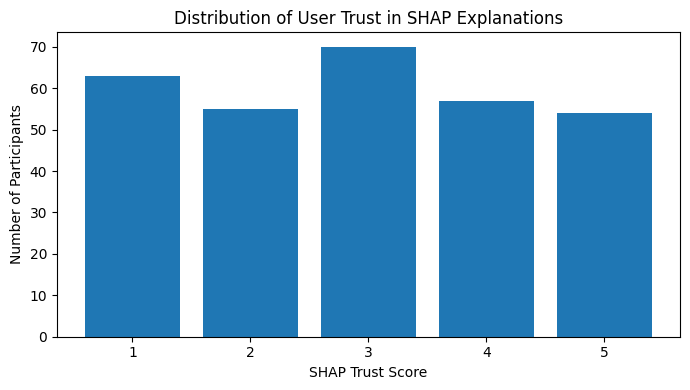

In [44]:
# ============================================================
# 32. DESCRIPTIVE TRUST STATISTICS
# ============================================================

trust_summary_rows = []

for variable, label in [
    ("Trust_SHAP_Likert", "SHAP Explanation Trust"),
    (
        "Trust_AI_With_Explanations_Score",
        "AI Trust With Explanations"
    )
]:
    if variable not in knust.columns:
        continue

    series = knust[variable].dropna()

    trust_summary_rows.append({
        "Measure": label,
        "N": len(series),
        "Mean": series.mean(),
        "Median": series.median(),
        "SD": series.std(ddof=1),
        "Minimum": series.min(),
        "Maximum": series.max()
    })

trust_summary = pd.DataFrame(trust_summary_rows)

print(trust_summary.round(3))

trust_summary.to_csv(
    OUTPUT_DIR / "Table_KNUST_Trust_Descriptive_Statistics.csv",
    index=False
)

# ============================================================
# 33. SHAP TRUST DISTRIBUTION
# ============================================================

if "Trust_SHAP_Likert" in knust.columns:
    trust_distribution = (
        knust["Trust_SHAP_Likert"]
        .value_counts()
        .sort_index()
    )

    print(trust_distribution)

    plt.figure(figsize=(7, 4))
    plt.bar(
        trust_distribution.index.astype(str),
        trust_distribution.values
    )

    plt.xlabel("SHAP Trust Score")
    plt.ylabel("Number of Participants")
    plt.title("Distribution of User Trust in SHAP Explanations")
    plt.tight_layout()

    plt.savefig(
        OUTPUT_DIR / "Figure_SHAP_Trust_Distribution.png",
        dpi=600,
        bbox_inches="tight"
    )

    plt.show()


In [45]:
# ============================================================
# 31B. MISSING-DATA, OUTLIER AND RUN-COMPLETION AUDIT
# ============================================================

# Explicit missing-value counts are reported rather than only describing
# the imputation policy.
phish_missing_by_column = phish_features.isna().sum()
uci_missing_by_column = X_uci_original.isna().sum()

missing_audit = pd.DataFrame({
    "Branch": ["PhishTank"] * len(phish_missing_by_column) + ["UCI"] * len(uci_missing_by_column),
    "Feature": list(phish_missing_by_column.index) + list(uci_missing_by_column.index),
    "Missing_Count": list(phish_missing_by_column.values) + list(uci_missing_by_column.values)
})
missing_audit.to_csv(OUTPUT_DIR / "Table_Missing_Value_Audit.csv", index=False)

print("PhishTank total missing feature values:", int(phish_features.isna().sum().sum()))
print("UCI total missing feature values before imputation:", int(X_uci_original.isna().sum().sum()))

# Outlier policy: no rows are removed solely because of extreme values.
# This is deliberate because Branch A is an anomaly-detection analysis and
# Branch B uses tree-based models. Extreme observations therefore remain in
# the data, while their counts are audited for transparency.
outlier_policy = pd.DataFrame({
    "Branch": ["PhishTank", "UCI"],
    "Policy": [
        "No outlier removal; Isolation Forest is intended to identify rare patterns.",
        "No outlier removal; tree-based classification is retained and exact duplicates are handled separately."
    ],
    "Reason": [
        "Removing rare observations before anomaly detection would alter the target of Branch A.",
        "Tree split rules do not require Gaussian outlier treatment; deleting observations could remove valid phishing patterns."
    ]
})
outlier_policy.to_csv(OUTPUT_DIR / "Table_Outlier_Policy.csv", index=False)
print("Outlier policy: no outlier rows removed; exact duplicate handling is separate.")

# Run-completion audit. These are populated from the authoritative per-seed
# tables after each configured experiment completes.
run_completion_rows = []
run_completion_rows.append({
    "Experiment": "Original XGBoost five-seed", "Expected_Runs": len(SEEDS),
    "Completed_Runs": len(legacy_xgb_results),
    "All_Completed": len(legacy_xgb_results) == len(SEEDS)
})
run_completion_rows.append({
    "Experiment": "De-duplicated XGBoost five-seed", "Expected_Runs": len(SEEDS),
    "Completed_Runs": len(xgb_runs_df),
    "All_Completed": len(xgb_runs_df) == len(SEEDS)
})
run_completion_rows.append({
    "Experiment": "Baseline classifiers", "Expected_Runs": len(SEEDS) * 4,
    "Completed_Runs": len(baseline_results),
    "All_Completed": len(baseline_results) == len(SEEDS) * 4
})
run_completion_rows.append({
    "Experiment": "Extended depth search", "Expected_Runs": len(SEEDS) * len(DEPTH_CANDIDATES),
    "Completed_Runs": len(depth_search),
    "All_Completed": len(depth_search) == len(SEEDS) * len(DEPTH_CANDIDATES)
})
run_completion = pd.DataFrame(run_completion_rows)
run_completion.to_csv(OUTPUT_DIR / "Table_Run_Completion_Audit.csv", index=False)
print("\nRun-completion audit:")
print(run_completion)
assert run_completion["All_Completed"].all(), "At least one configured experiment did not complete."


PhishTank total missing feature values: 0
UCI total missing feature values before imputation: 0
Outlier policy: no outlier rows removed; exact duplicate handling is separate.

Run-completion audit:
                        Experiment  Expected_Runs  Completed_Runs  \
0       Original XGBoost five-seed              5               5   
1  De-duplicated XGBoost five-seed              5               5   
2             Baseline classifiers             20              20   
3            Extended depth search             25              25   

   All_Completed  
0           True  
1           True  
2           True  
3           True  


                      Measure  Mean Score
0      SHAP Explanation Trust       2.946
1  AI Trust With Explanations       3.120


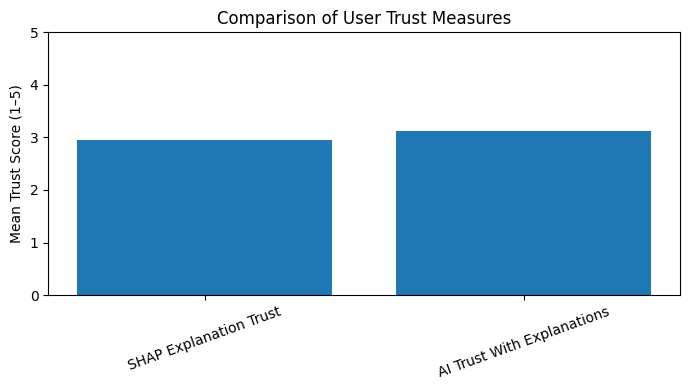

In [46]:
# ============================================================
# 34. TRUST COMPARISON
# ============================================================

comparison_rows = []

if "Trust_SHAP_Likert" in knust.columns:
    comparison_rows.append({
        "Measure": "SHAP Explanation Trust",
        "Mean Score": knust["Trust_SHAP_Likert"].mean()
    })

if "Trust_AI_With_Explanations_Score" in knust.columns:
    comparison_rows.append({
        "Measure": "AI Trust With Explanations",
        "Mean Score": (
            knust["Trust_AI_With_Explanations_Score"].mean()
        )
    })

trust_comparison = pd.DataFrame(comparison_rows)

print(trust_comparison.round(3))

if not trust_comparison.empty:
    plt.figure(figsize=(7, 4))

    plt.bar(
        trust_comparison["Measure"],
        trust_comparison["Mean Score"]
    )

    plt.ylabel("Mean Trust Score (1–5)")
    plt.title("Comparison of User Trust Measures")
    plt.xticks(rotation=20)
    plt.ylim(0, 5)
    plt.tight_layout()

    plt.savefig(
        OUTPUT_DIR / "Figure_Trust_Comparison.png",
        dpi=600,
        bbox_inches="tight"
    )

    plt.show()

trust_comparison.to_csv(
    OUTPUT_DIR / "Table_Trust_Comparison.csv",
    index=False
)

  Preference  Count  Percentage
0       SHAP     84       28.09
1       LIME     77       25.75
2       Both     72       24.08
3    Neither     66       22.07


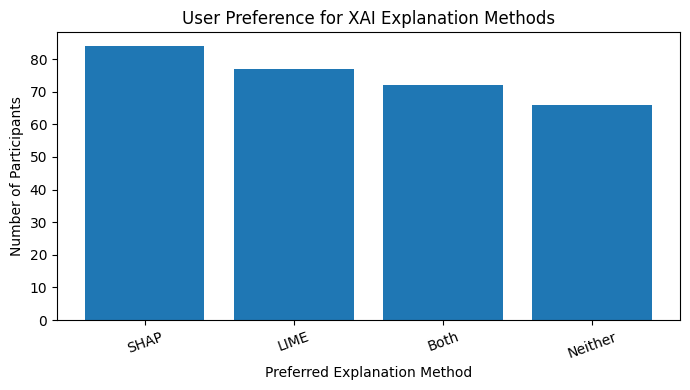

In [47]:
# ============================================================
# 35. PREFERRED EXPLANATION METHOD
# ============================================================

if "Preferred_Explanation" in knust.columns:
    preference = (
        knust["Preferred_Explanation"]
        .astype(str)
        .str.strip()
        .value_counts()
    )

    preference_table = pd.DataFrame({
        "Preference": preference.index,
        "Count": preference.values,
        "Percentage": (
            preference.values
            / preference.values.sum()
            * 100
        ).round(2)
    })

    print(preference_table)

    plt.figure(figsize=(7, 4))

    plt.bar(
        preference_table["Preference"],
        preference_table["Count"]
    )

    plt.xlabel("Preferred Explanation Method")
    plt.ylabel("Number of Participants")
    plt.title("User Preference for XAI Explanation Methods")
    plt.xticks(rotation=20)
    plt.tight_layout()

    plt.savefig(
        OUTPUT_DIR / "Figure_Preferred_Explanation_Method.png",
        dpi=600,
        bbox_inches="tight"
    )

    plt.show()

    preference_table.to_csv(
        OUTPUT_DIR / "Table_Preferred_Explanation_Method.csv",
        index=False
    )

In [48]:
# ============================================================
# 36. SHAP TRUST CATEGORY
# ============================================================

if "Trust_SHAP_Likert" in knust.columns:
    knust["SHAP_Trust_Category"] = pd.cut(
        knust["Trust_SHAP_Likert"],
        bins=[0, 2, 3, 5],
        labels=[
            "Low Trust",
            "Neutral Trust",
            "High Trust"
        ],
        include_lowest=True
    )

    trust_categories = (
        knust["SHAP_Trust_Category"]
        .value_counts()
        .sort_index()
    )

    print(trust_categories)

    trust_categories.to_csv(
        OUTPUT_DIR / "Table_SHAP_Trust_Categories.csv"
    )

SHAP_Trust_Category
Low Trust        118
Neutral Trust     70
High Trust       111
Name: count, dtype: int64


In [49]:
# ============================================================
# 37. CHI-SQUARE TEST + CRAMER'S V
# ============================================================

from scipy.stats import chi2_contingency

if (
    "SHAP_Trust_Category" in knust.columns
    and "Preferred_Explanation" in knust.columns
):
    contingency = pd.crosstab(
        knust["SHAP_Trust_Category"],
        knust["Preferred_Explanation"]
    )

    print("Contingency table:")
    print(contingency)

    chi2, p_value, dof, expected = chi2_contingency(
        contingency
    )

    n = contingency.to_numpy().sum()
    min_dim = min(contingency.shape) - 1

    cramers_v = (
        np.sqrt(chi2 / (n * min_dim))
        if min_dim > 0
        else np.nan
    )

    print("Chi-square:", round(chi2, 4))
    print("Degrees of freedom:", dof)
    print("p-value:", round(p_value, 5))
    print("Cramer's V:", round(cramers_v, 4))

    chi_square_results = pd.DataFrame({
        "Statistic": [
            "Chi-square",
            "Degrees of freedom",
            "p-value",
            "Cramer's V"
        ],
        "Value": [
            chi2,
            dof,
            p_value,
            cramers_v
        ]
    })

    chi_square_results.to_csv(
        OUTPUT_DIR / "Table_ChiSquare_CramersV.csv",
        index=False
    )

Contingency table:
Preferred_Explanation  Both  LIME  Neither  SHAP
SHAP_Trust_Category                             
Low Trust                36    27       26    29
Neutral Trust            15    17       18    20
High Trust               21    33       22    35
Chi-square: 6.2434
Degrees of freedom: 6
p-value: 0.39648
Cramer's V: 0.1022


In [50]:
# ============================================================
# 38. PAIRED TRUST TEST, EFFECT SIZE, CONFIDENCE INTERVAL + SPEARMAN
# ============================================================

from scipy.stats import spearmanr, wilcoxon, rankdata

candidate_ai_trust_columns = [
    "AI_Trust_Score",
    "Trust_AI_With_Explanations_Score"
]

ai_column = next(
    (c for c in candidate_ai_trust_columns if c in knust.columns),
    None
)

if (
    "Trust_SHAP_Likert" in knust.columns
    and ai_column is not None
):
    paired = (
        knust[["Trust_SHAP_Likert", ai_column]]
        .apply(pd.to_numeric, errors="coerce")
        .dropna()
    )

    shap_scores = paired["Trust_SHAP_Likert"].to_numpy(dtype=float)
    ai_scores = paired[ai_column].to_numpy(dtype=float)
    differences = shap_scores - ai_scores

    # Wilcoxon signed-rank test for paired ordinal measures.
    wilcoxon_result = wilcoxon(
        shap_scores,
        ai_scores,
        alternative="two-sided",
        zero_method="wilcox",
        method="auto"
    )

    nonzero = differences[differences != 0]
    abs_ranks = rankdata(np.abs(nonzero), method="average")
    w_plus = float(abs_ranks[nonzero > 0].sum())
    w_minus = float(abs_ranks[nonzero < 0].sum())

    rank_biserial = (
        (w_plus - w_minus) / (w_plus + w_minus)
        if (w_plus + w_minus) > 0 else np.nan
    )

    # Bootstrap 95% CI for the paired mean difference.
    rng = np.random.default_rng(42)
    boot_means = np.empty(10000)

    for b in range(len(boot_means)):
        sample = rng.choice(
            differences,
            size=len(differences),
            replace=True
        )
        boot_means[b] = np.mean(sample)

    ci_low, ci_high = np.percentile(
        boot_means,
        [2.5, 97.5]
    )

    print("Paired trust comparison:")
    print("N:", len(paired))
    print("SHAP-trust mean:", round(shap_scores.mean(), 4))
    print("Overall-AI-trust mean:", round(ai_scores.mean(), 4))
    print("Mean paired difference (SHAP - AI):", round(differences.mean(), 4))
    print("Wilcoxon statistic:", round(float(wilcoxon_result.statistic), 4))
    print("Wilcoxon p-value:", round(float(wilcoxon_result.pvalue), 6))
    print("Rank-biserial effect size:", round(rank_biserial, 4))
    print("95% bootstrap CI for mean paired difference:",
          (round(ci_low, 4), round(ci_high, 4)))

    paired_test_results = pd.DataFrame({
        "N": [len(paired)],
        "SHAP_Trust_Mean": [shap_scores.mean()],
        "AI_Trust_Mean": [ai_scores.mean()],
        "Mean_Paired_Difference": [differences.mean()],
        "Wilcoxon_Statistic": [float(wilcoxon_result.statistic)],
        "Wilcoxon_p": [float(wilcoxon_result.pvalue)],
        "Rank_Biserial": [rank_biserial],
        "CI95_Low": [ci_low],
        "CI95_High": [ci_high]
    })

    paired_test_results.to_csv(
        OUTPUT_DIR / "Table_Paired_Trust_Wilcoxon_Effect_CI.csv",
        index=False
    )

    # Spearman remains an association test and is not interpreted causally.
    rho, p_value = spearmanr(
        paired["Trust_SHAP_Likert"],
        paired[ai_column]
    )

    print("\nSpearman association:")
    print("rho:", round(rho, 4))
    print("p-value:", round(p_value, 6))
    print("N:", len(paired))

    spearman_results = pd.DataFrame({
        "Variable_1": ["Trust_SHAP_Likert"],
        "Variable_2": [ai_column],
        "Spearman_rho": [rho],
        "p_value": [p_value],
        "N": [len(paired)]
    })

    spearman_results.to_csv(
        OUTPUT_DIR / "Table_Spearman_Trust_Correlation.csv",
        index=False
    )

else:
    print(
        "Paired trust and Spearman analyses were not executed because "
        "the required survey columns were unavailable."
    )


Paired trust comparison:
N: 299
SHAP-trust mean: 2.9465
Overall-AI-trust mean: 3.1204
Mean paired difference (SHAP - AI): -0.1739
Wilcoxon statistic: 13143.0
Wilcoxon p-value: 0.147333
Rank-biserial effect size: -0.106
95% bootstrap CI for mean paired difference: (np.float64(-0.4013), np.float64(0.0502))

Spearman association:
rho: -0.0092
p-value: 0.874728
N: 299


In [51]:
# ============================================================
# 38B. TRUST-INCREASE PROPORTION CI + RF VS XGBOOST PAIRED TEST
# ============================================================

# 46.5% was previously reported descriptively. Add an exact 95% binomial
# confidence interval so the uncertainty around the proportion is explicit.
if "Trust_AI_With_Explanations_Score" in knust.columns and "Trust_SHAP_Likert" in knust.columns:
    paired_trust = knust[["Trust_SHAP_Likert", "Trust_AI_With_Explanations_Score"]].apply(
        pd.to_numeric, errors="coerce"
    ).dropna()
    increased = int((paired_trust["Trust_SHAP_Likert"] > paired_trust["Trust_AI_With_Explanations_Score"]).sum())
    unchanged = int((paired_trust["Trust_SHAP_Likert"] == paired_trust["Trust_AI_With_Explanations_Score"]).sum())
    decreased = int((paired_trust["Trust_SHAP_Likert"] < paired_trust["Trust_AI_With_Explanations_Score"]).sum())
    n_pair = len(paired_trust)
    prop = increased / n_pair if n_pair else np.nan
    bt = binomtest(increased, n_pair, p=0.5) if n_pair else None
    ci = bt.proportion_ci(confidence_level=0.95, method="wilson") if bt else None

    trust_increase_ci = pd.DataFrame({
        "N": [n_pair], "Increased_n": [increased], "Increased_Percent": [100*prop],
        "Unchanged_n": [unchanged], "Decreased_n": [decreased],
        "CI95_Low": [100*ci.low if ci else np.nan],
        "CI95_High": [100*ci.high if ci else np.nan]
    })
    print("Trust increased:", increased, "of", n_pair, f"({100*prop:.2f}%)")
    print("95% Wilson CI:", (100*ci.low, 100*ci.high) if ci else None)
    trust_increase_ci.to_csv(OUTPUT_DIR / "Table_Trust_Increased_Proportion_CI.csv", index=False)

# Random Forest vs XGBoost: five paired seed-level accuracy observations.
# With only five pairs, the test is explicitly treated as descriptive/supporting
# evidence rather than as a strong population-level inferential claim.
if set(["Random Forest", "XGBoost"]).issubset(set(baseline_results["Model"])):
    rf = baseline_results[baseline_results["Model"] == "Random Forest"].set_index("Seed")["Accuracy"]
    xgb_acc = baseline_results[baseline_results["Model"] == "XGBoost"].set_index("Seed")["Accuracy"]
    paired_acc = pd.concat([rf.rename("RF"), xgb_acc.rename("XGBoost")], axis=1).dropna()
    if len(paired_acc) >= 2:
        rf_xgb_w = wilcoxon(paired_acc["RF"], paired_acc["XGBoost"], alternative="two-sided", method="auto")
        deltas = paired_acc["RF"] - paired_acc["XGBoost"]
        nonzero = deltas[deltas != 0]
        ranks = rankdata(np.abs(nonzero), method="average")
        rb = ((ranks[nonzero > 0].sum() - ranks[nonzero < 0].sum()) /
              (ranks[nonzero > 0].sum() + ranks[nonzero < 0].sum())) if len(nonzero) else np.nan
        rf_xgb_test = pd.DataFrame({
            "N_Paired_Seeds": [len(paired_acc)],
            "Mean_Accuracy_Difference_RF_minus_XGB": [deltas.mean()],
            "Min_Difference": [deltas.min()], "Max_Difference": [deltas.max()],
            "Wilcoxon_Statistic": [float(rf_xgb_w.statistic)],
            "Wilcoxon_p": [float(rf_xgb_w.pvalue)],
            "Rank_Biserial": [rb]
        })
        print("\nRF vs XGBoost paired seed-level accuracy:")
        print(rf_xgb_test.round(5))
        rf_xgb_test.to_csv(OUTPUT_DIR / "Table_RF_vs_XGBoost_Paired_Seed_Test.csv", index=False)


Trust increased: 114 of 299 (38.13%)
95% Wilson CI: (np.float64(32.80536758431355), np.float64(43.750022065279445))

RF vs XGBoost paired seed-level accuracy:
   N_Paired_Seeds  Mean_Accuracy_Difference_RF_minus_XGB  Min_Difference  \
0               5                                -0.0021        -0.00611   

   Max_Difference  Wilcoxon_Statistic  Wilcoxon_p  Rank_Biserial  
0         0.00175                 3.5       0.375       -0.53333  


In [52]:
# ============================================================
# 39. SAVE FINAL MODEL ARTIFACTS + TRACEABILITY CHECKS
# ============================================================

joblib.dump(
    final_model,
    OUTPUT_DIR / "UCI_XGBoost_Phishing_Model.pkl"
)

joblib.dump(
    final_imputer,
    OUTPUT_DIR / "UCI_XGBoost_Imputer.pkl"
)

joblib.dump(
    X_uci_raw.columns.tolist(),
    OUTPUT_DIR / "UCI_Feature_Names.pkl"
)

final_runs_df.to_csv(
    OUTPUT_DIR / "Table_Final_Vanilla_Five_Seed_Results.csv",
    index=False
)

final_summary.to_csv(
    OUTPUT_DIR / "Table_Final_Vanilla_Mean_SD.csv"
)

print(
    "Final model and result tables saved to:",
    OUTPUT_DIR.resolve()
)

# ============================================================
# 40. FINAL SANITY CHECKS
# ============================================================

print("========== FINAL SANITY CHECK ==========")

print("UCI source rows:", len(uci))
print("UCI rows after de-duplication:", len(X_uci_raw))
print("UCI features:", X_uci_raw.shape[1])
print("UCI legitimate:", int((y_uci == 0).sum()))
print("UCI phishing:", int((y_uci == 1).sum()))

assert X_uci_raw.shape[1] == 30
assert len(X_uci_raw) == len(y_uci)
assert set(y_uci.unique()).issubset({0, 1})

assert len(SEEDS) == 5
assert len(set(SEEDS)) == 5
assert tn + fp + fn + tp == len(y_test_final)
assert stability_long["Seed"].nunique() == 5
assert set(stability_long["Seed"]) == set(SEEDS)
assert feature_duplicate_count >= 0
assert feature_label_duplicate_count >= 0

print("Selected depth:", SELECTED_DEPTH)
print("SMOTE in final model: OFF")
print("Exact duplicate feature rows audited:", feature_duplicate_count)
print("Exact duplicate feature+label rows audited:", feature_label_duplicate_count)
print("No unsupported UCI/PhishTank feature fusion: True")
print("SHAP/LIME are post-hoc and do not alter predictions: True")
print("Final evaluation set is de-duplicated before splitting: True")
print("All configured five-seed final runs completed: True")
print("Sanity checks completed successfully.")


Final model and result tables saved to: /kaggle/working/revised_outputs
========== FINAL SANITY CHECK ==========
UCI source rows: 11055
UCI rows after de-duplication: 5721
UCI features: 30
UCI legitimate: 2766
UCI phishing: 2955
Selected depth: 6
SMOTE in final model: OFF
Exact duplicate feature rows audited: 5270
Exact duplicate feature+label rows audited: 5206
No unsupported UCI/PhishTank feature fusion: True
SHAP/LIME are post-hoc and do not alter predictions: True
Final evaluation set is de-duplicated before splitting: True
All configured five-seed final runs completed: True
Sanity checks completed successfully.
